# Crypto XS Momentum: step by step

The tutorial version of `02_crypto_xs_momentum.ipynb`. Same data, same code, but every step is drawn on real data, one part per lesson.

| Part | Lesson | Sections |
| --- | --- | --- |
| 1 · The signal | 2.5 | 1 to 8 |
| 2 · Sizing: from signal to dollars | 2.6 | 9 to 15 |
| 3 · Reading the backtest | 2.7 | 16 to 22 |
| 4 · When it works, when it breaks | 2.8 | 23 to 28 |
| 5 · What the Sharpe is really worth | 2.10 | 29 to 31 |

Run it top to bottom once (a few minutes, section 8 writes a GIF).

# Part 1 · Lesson 2.5: the signal

## 0. Setup

The code of notebook 02, sections 1 to 3, in one cell.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = "../data_trend"
PPY = 365                       # crypto trades every day
TARGET_VOL = 0.20               # per strategy; the book will run lower
FEE_BPS = 5.0                   # one-way cost assumption
BUFFER = 0.10                   # do not trade if the gap to the ideal position is below 10 %
N_UNIVERSE = 20                 # names held at any time (beyond that, names get small, noisy and costly to trade)
plt.rcParams.update({"figure.figsize": (12, 4.5), "axes.grid": True, "grid.alpha": .3})

long = pd.read_parquet(f"{DATA}/prices_funding.parquet")
PX   = long.pivot(index="date", columns="symbol", values="close").sort_index()
FUND = long.pivot(index="date", columns="symbol", values="funding_rate").reindex(PX.index).fillna(0.0)
VOLUME = pd.read_parquet(f"{DATA}/volume_all_perps.parquet").reindex(PX.index)   # quote volume, all perps ever
meta = pd.read_csv(f"{DATA}/perp_meta.csv")
today40 = pd.read_csv(f"{DATA}/universe_today.csv")["symbol"].tolist()

print(f"{PX.shape[1]} names with prices, {VOLUME.shape[1]} names with volume, {PX.index.min():%Y-%m-%d} -> {PX.index.max():%Y-%m-%d}")


def point_in_time_universe(volume, n=N_UNIVERSE, win=30, min_age=180, max_gap=14):
    """Boolean table (date x name): True = in the universe that day. Uses only past data."""
    is_crypto = dict(zip(meta.symbol, meta.underlying_type))
    vol = volume[[c for c in volume.columns if is_crypto.get(c, "COIN") == "COIN"]]

    # days listed in the current listing episode (a gap > 14 days restarts the count: recycled tickers)
    age = pd.DataFrame(np.nan, index=vol.index, columns=vol.columns)
    for c in vol.columns:
        days = vol[c].dropna().index
        if len(days):
            episode = (days.to_series().diff().dt.days > max_gap).cumsum()
            age.loc[days, c] = episode.groupby(episode).cumcount().values + 1

    score = vol.rolling(win, min_periods=win).mean().shift(1)            # known before today
    eligible = score.notna() & (age.shift(1) >= min_age)
    rank = score.where(eligible).rank(axis=1, ascending=False, method="first").values

    buffer = n // 4
    members = np.zeros(rank.shape, bool)
    current = np.zeros(rank.shape[1], bool)
    for i in range(len(rank)):
        ok = ~np.isnan(rank[i]) & (rank[i] <= n + buffer)
        current = current & ok                            # leave only beyond n + buffer
        free = n - current.sum()
        if free > 0:                                      # fill free slots with the best-ranked outsiders
            cand = np.where(~current & ok)[0]
            current[cand[np.argsort(rank[i][cand])][:free]] = True
        members[i] = current
    return pd.DataFrame(members, index=vol.index, columns=vol.columns)

M_PIT = point_in_time_universe(VOLUME).reindex(columns=PX.columns).fillna(False) & PX.notna()

# the frozen control: today's top 20 by volume, whenever they have a price (and 180 days of history)
today20 = VOLUME.tail(30).mean()[[c for c in today40 if c in VOLUME.columns]].nlargest(N_UNIVERSE).index.tolist()
listed_days = PX.notna().cumsum()
M_FROZEN = pd.DataFrame({c: (c in today20) & PX[c].notna() & (listed_days[c] >= 180) for c in PX.columns})

print(f"point-in-time : {M_PIT.any().sum()} names ever in the universe, {M_PIT.sum(axis=1).median():.0f} held per day (median)")
print(f"frozen        : {M_FROZEN.any().sum()} names, {M_FROZEN.sum(axis=1).median():.0f} held per day (median)")
churn = M_PIT.astype(int).diff().abs().sum(axis=1).resample("YE").sum()
print("entries + exits per year, point-in-time:", churn.astype(int).to_dict())


def ewma_vol(px, span=32):
    """Daily volatility, exponentially weighted. Blended with its long-run mean so it never collapses."""
    fast = px.pct_change(fill_method=None).ewm(span=span, min_periods=20).std()
    slow = fast.rolling(10 * PPY, min_periods=PPY).mean()
    return 0.7 * fast + 0.3 * slow.fillna(fast.expanding(min_periods=1).mean())

VOL_D = ewma_vol(PX)                                   # daily
VOL_A = VOL_D * np.sqrt(PPY)                           # annualised
Z = PX.pct_change(fill_method=None) / VOL_D                            # vol-adjusted daily returns

HORIZONS = (7, 30, 90)
speeds = {}
for h in HORIZONS:
    s = Z.rolling(h, min_periods=h).sum().shift(1)                       # skip today's bar
    s = s.ewm(span=max(2, round(h / 4)), min_periods=1).mean()           # smooth
    speeds[h] = s / np.sqrt(h)                                           # comparable scale

# FDM: one number, from the average correlation between the three speeds (pooled over names)
rho = np.nanmean([speeds[a].corrwith(speeds[b]).median() for a in HORIZONS for b in HORIZONS if a < b])
FDM = 1 / np.sqrt((1 + 2 * rho) / 3)
raw = sum(speeds.values()) / 3 * FDM
print(f"average correlation between speeds {rho:.2f} -> FDM {FDM:.2f}")

def cross_sectional_forecast(raw, members, cap=20):
    """Directional score -> market-neutral forecast, avg |f| = 10, capped, sum of positions = 0."""
    w = members.div(members.sum(axis=1), axis=0).fillna(0.0)             # 1/n on the day's members
    k = (w / VOL_A).where(members)                                        # position per unit of forecast
    s = raw.where(members)
    def demean(f):
        return f.sub((f * k).sum(axis=1) / k.sum(axis=1), axis=0)
    f = demean(s)
    f = f.mul(10 / f.abs().mean(axis=1).expanding(min_periods=PPY).mean(), axis=0)   # pooled scale, past only
    for _ in range(20):                                                    # cap, then re-centre, until stable
        f = demean(f.clip(-cap, cap))
    return f.where(members, 0.0), w

FC_PIT, W_PIT = cross_sectional_forecast(raw, M_PIT)
FC_FRZ, W_FRZ = cross_sectional_forecast(raw, M_FROZEN)

d = FC_PIT.dropna(how="all").index[-1]
print(f"\nForecast on {d:%Y-%m-%d}, strongest and weakest:")
print(FC_PIT.loc[d][M_PIT.loc[d]].sort_values().round(1).iloc[[0, 1, 2, -3, -2, -1]].to_string())

450 names with prices, 832 names with volume, 2019-12-31 -> 2026-08-24


/sessions/rcw-01bjyvmp9cq5hisor6mgbcjf/tmp/ipykernel_43/3454615234.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  M_PIT = point_in_time_universe(VOLUME).reindex(columns=PX.columns).fillna(False) & PX.notna()


point-in-time : 176 names ever in the universe, 20 held per day (median)
frozen        : 20 names, 12 held per day (median)
entries + exits per year, point-in-time: {Timestamp('2019-12-31 00:00:00'): 0, Timestamp('2020-12-31 00:00:00'): 26, Timestamp('2021-12-31 00:00:00'): 72, Timestamp('2022-12-31 00:00:00'): 142, Timestamp('2023-12-31 00:00:00'): 132, Timestamp('2024-12-31 00:00:00'): 148, Timestamp('2025-12-31 00:00:00'): 102, Timestamp('2026-12-31 00:00:00'): 98}


average correlation between speeds 0.30 -> FDM 1.37



Forecast on 2026-08-24, strongest and weakest:
symbol
BEATUSDT   -20.0
CYSUSDT    -20.0
DEXEUSDT   -20.0
HYPEUSDT    11.8
ZECUSDT     17.8
TUTUSDT     19.6


In [2]:
# colours used in every chart, the same as the slides
ORANGE, BLUE, GREY, DARK, PAPER = "#c8661f", "#2f5d8a", "#b8b2a6", "#1b1d21", "#fbf9f5"
plt.rcParams.update({"figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": "#5e636b",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.xmargin": 0.01, "font.size": 11})
nm = lambda s: s.replace("USDT", "") if s.isascii() else "BINANCELIFE"   # one ticker is written in Chinese characters

def finish():
    """Drop the date labels on the x axis, then show."""
    for a in plt.gcf().axes:
        a.set_xlabel("")
    plt.tight_layout(); plt.show()

LAST = FC_PIT.dropna(how="all").index[-1]
print(f"last day in the data: {LAST:%Y-%m-%d}")

last day in the data: 2026-08-24


## 1. Vol-adjust

A memecoin moves several times more than Bitcoin every day. Rank raw returns, and you rank volatility. Divide each daily return by the coin's own volatility, and both move on the same scale.

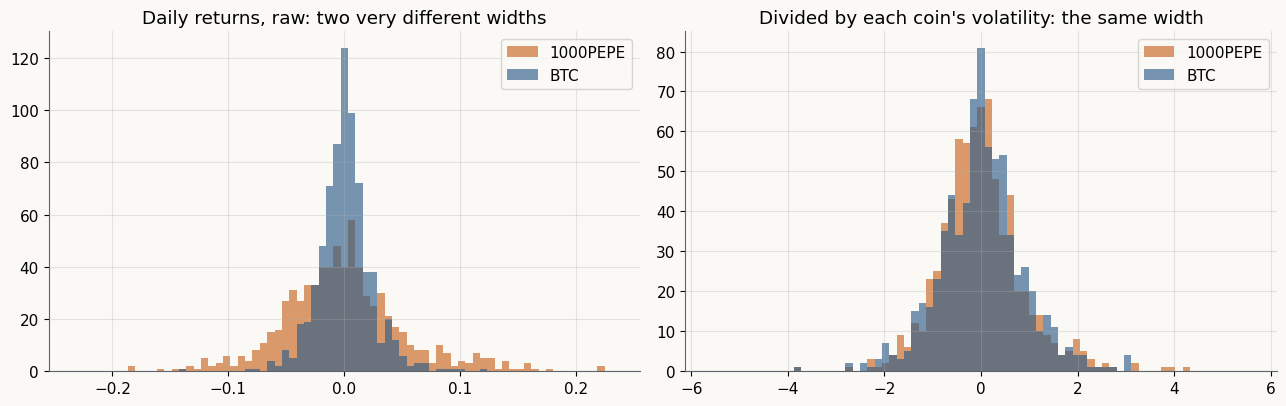

          daily std, raw %  daily std, vol-adjusted
symbol                                             
BTC                   2.33                     0.86
1000PEPE              5.99                     0.88


In [3]:
A, B = "BTCUSDT", "1000PEPEUSDT"
since = LAST - pd.Timedelta(days=730)
r = PX[[A, B]].pct_change(fill_method=None).loc[since:]
z = Z[[A, B]].loc[since:]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
bins = np.linspace(-0.25, 0.25, 80)
for c, col in ((B, ORANGE), (A, BLUE)):
    ax[0].hist(r[c].dropna(), bins=bins, alpha=.65, color=col, label=nm(c))
    ax[1].hist(z[c].dropna(), bins=np.linspace(-6, 6, 80), alpha=.65, color=col, label=nm(c))
ax[0].set_title("Daily returns, raw: two very different widths"); ax[0].legend()
ax[1].set_title("Divided by each coin's volatility: the same width"); ax[1].legend()
finish()

print(pd.DataFrame({"daily std, raw %": r.std() * 100, "daily std, vol-adjusted": z.std()}).rename(index=nm).round(2).to_string())

## 2. Three speeds

For each coin, the vol-adjusted returns summed over 7, 30 and 90 days (today skipped). Here on SOL: the fast speed reacts first and flips often, the slow one is late but steady. Notice also the **size**: the 90-day line swings much wider. Step 4 deals with that.

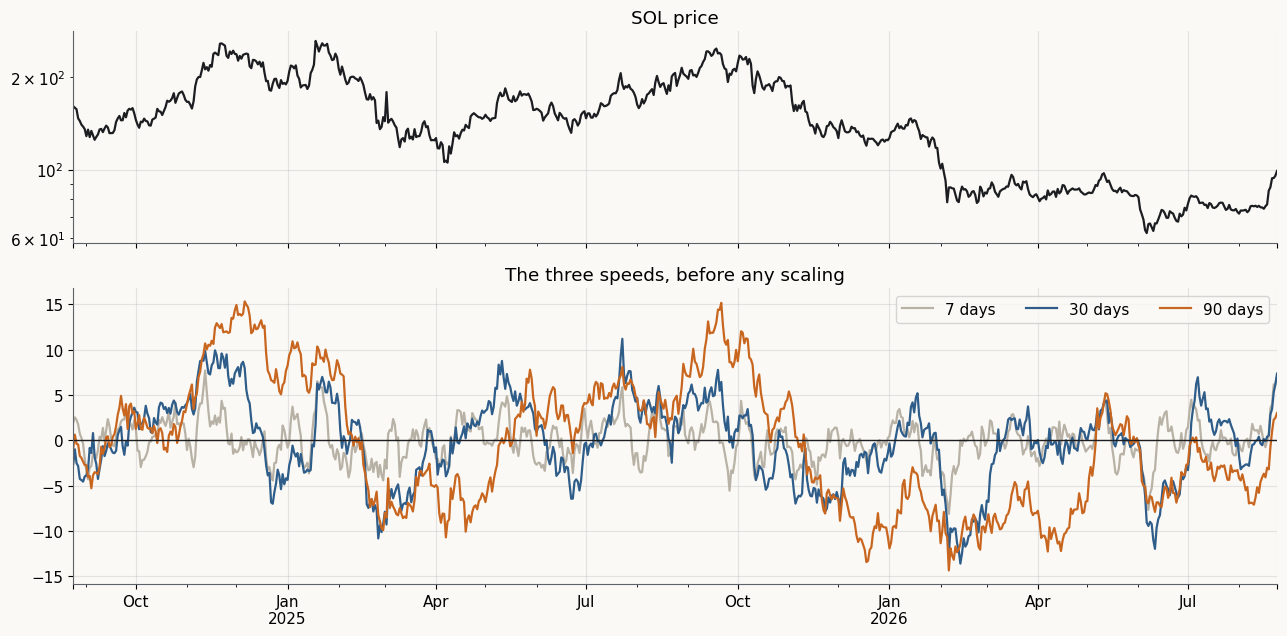

In [4]:
C = "SOLUSDT"
since = LAST - pd.Timedelta(days=730)
raw_speed = {h: Z[C].rolling(h, min_periods=h).sum().shift(1).loc[since:] for h in HORIZONS}

fig, ax = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True, height_ratios=[1, 1.4])
PX[C].loc[since:].plot(ax=ax[0], color=DARK, lw=1.6); ax[0].set_yscale("log"); ax[0].set_title(f"{nm(C)} price")
for h, col in zip(HORIZONS, (GREY, BLUE, ORANGE)):
    raw_speed[h].plot(ax=ax[1], color=col, lw=1.6, label=f"{h} days")
ax[1].axhline(0, color=DARK, lw=1); ax[1].legend(ncol=3); ax[1].set_title("The three speeds, before any scaling")
finish()

## 3. Smooth

Every time a speed crosses zero, the position flips from long to short, and every flip is paid at the spread. A light moving average (about a quarter of the horizon: 2, 8 and 22 days) keeps the direction and removes most of the flips. Below, the 30-day speed of SOL, raw and smoothed over 8 days; then the count of flips for the three speeds, over the whole universe.

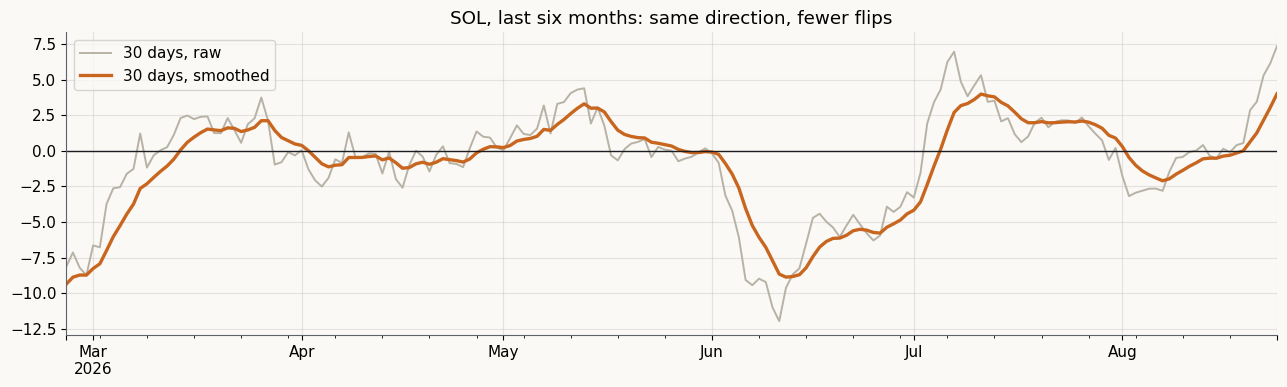

         sign flips per name per year, raw  smoothed
7 days                                65.0      47.2
30 days                               28.3      10.1
90 days                               13.2       3.2


In [5]:
since = LAST - pd.Timedelta(days=180)
fast = Z[C].rolling(30, min_periods=30).sum().shift(1)
fast_s = fast.ewm(span=8, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 4))
fast.loc[since:].plot(ax=ax, color=GREY, lw=1.4, label="30 days, raw")
fast_s.loc[since:].plot(ax=ax, color=ORANGE, lw=2.4, label="30 days, smoothed")
ax.axhline(0, color=DARK, lw=1); ax.legend(); ax.set_title(f"{nm(C)}, last six months: same direction, fewer flips")
finish()

# how many zero crossings per year, pooled over the names while they are in the universe
rows = {}
for h in HORIZONS:
    s = Z.rolling(h, min_periods=h).sum().shift(1).where(M_PIT)
    sm = s.ewm(span=max(2, round(h / 4)), min_periods=1).mean().where(M_PIT)
    flips = lambda x: (np.sign(x).diff().abs() > 0).sum().sum() / M_PIT.sum().sum() * PPY
    rows[f"{h} days"] = {"sign flips per name per year, raw": flips(s), "smoothed": flips(sm)}
print(pd.DataFrame(rows).T.round(1).to_string())

## 4. One scale, then average

A sum of *h* vol-adjusted days has a size of about √h: daily moves partly cancel out. Divide each speed by √h and the three are the same size. Then average them, and multiply by the FDM (averaging correlated signals shrinks them; the FDM scales back).

         size before (std)    √h  size after ÷ √h
7 days                2.36  2.65             0.85
30 days               5.54  5.48             0.97
90 days               9.98  9.49             1.01


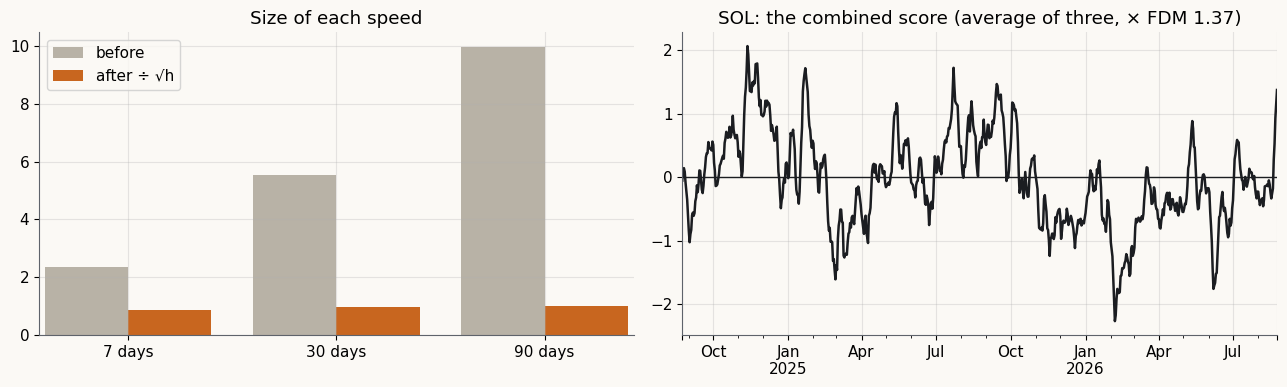

In [6]:
before = {h: Z.rolling(h, min_periods=h).sum().shift(1).where(M_PIT).stack().dropna().std() for h in HORIZONS}
after = {h: speeds[h].where(M_PIT).stack().dropna().std() for h in HORIZONS}
tab = pd.DataFrame({"size before (std)": before, "√h": {h: np.sqrt(h) for h in HORIZONS}, "size after ÷ √h": after})
tab.index = [f"{h} days" for h in HORIZONS]
print(tab.round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(3)
ax[0].bar(x - .2, tab.iloc[:, 0], .4, color=GREY, label="before"); ax[0].bar(x + .2, tab.iloc[:, 2], .4, color=ORANGE, label="after ÷ √h")
ax[0].set_xticks(x, tab.index); ax[0].legend(); ax[0].set_title("Size of each speed")
since = LAST - pd.Timedelta(days=730)
(raw[C].loc[since:]).plot(ax=ax[1], color=DARK, lw=1.8); ax[1].axhline(0, color=DARK, lw=1)
ax[1].set_title(f"{nm(C)}: the combined score (average of three, × FDM {FDM:.2f})")
finish()

## 5. Rank against the others

**One day.** On the last day, almost every coin has a positive score: the market went up. Subtract the average of the universe, and only the ranking is left.

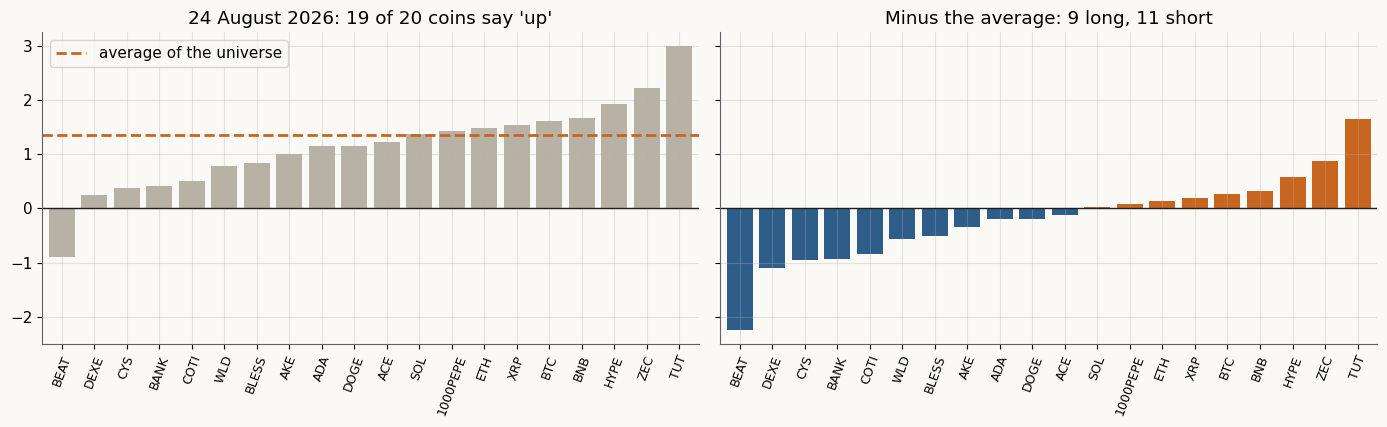

In [7]:
mem = M_PIT.loc[LAST][M_PIT.loc[LAST]].index
s = raw.loc[LAST, mem].sort_values()
k = (1 / VOL_A.loc[LAST, mem])
wavg = (s * k[s.index]).sum() / k.sum()
after_ = s - wavg

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
ax[0].bar(range(len(s)), s, color=GREY); ax[0].axhline(wavg, color=ORANGE, ls="--", lw=2, label="average of the universe")
ax[0].set_title(f"{LAST:%d %B %Y}: {(s > 0).sum()} of {len(s)} coins say 'up'"); ax[0].legend()
ax[1].bar(range(len(s)), after_, color=np.where(after_ > 0, ORANGE, BLUE))
ax[1].set_title(f"Minus the average: {(after_ > 0).sum()} long, {(after_ < 0).sum()} short")
for a in ax:
    a.axhline(0, color=DARK, lw=1); a.set_xticks(range(len(s)), [nm(c) for c in s.index], rotation=70, fontsize=9)
finish()

**Every day.** Why a *weighted* average? A position is forecast ÷ volatility, so calm coins get more dollars. Subtract a plain average and the forecasts cancel, the dollars do not: the book drifts short, because BTC, ETH and BNB often sit below the average. Weighted by 1 / vol: always zero.

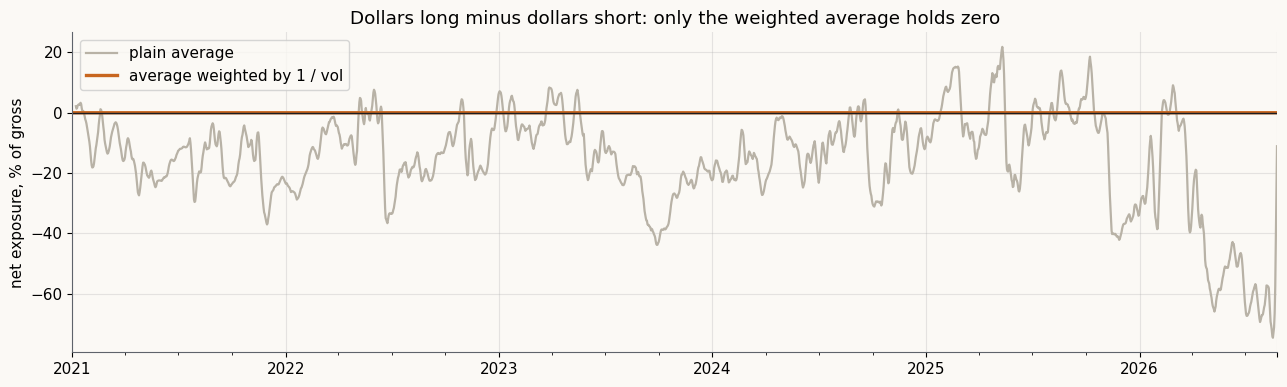

plain average: net exposure between -49 % and 7 % of gross (5-95 %)


In [8]:
S = raw.where(M_PIT)
plain = S.sub(S.mean(axis=1), axis=0)
weighted = S.sub((S / VOL_A).sum(axis=1) / (1 / VOL_A).where(M_PIT).sum(axis=1), axis=0)
def net_share(f):
    pos = f / VOL_A
    return (pos.sum(axis=1) / pos.abs().sum(axis=1) * 100).loc["2021":]

fig, ax = plt.subplots(figsize=(13, 4))
net_share(plain).rolling(7).mean().plot(ax=ax, color=GREY, lw=1.6, label="plain average")
net_share(weighted).plot(ax=ax, color=ORANGE, lw=2.4, label="average weighted by 1 / vol")
ax.axhline(0, color=DARK, lw=1); ax.legend(); ax.set_ylabel("net exposure, % of gross")
ax.set_title("Dollars long minus dollars short: only the weighted average holds zero")
finish()
print(f"plain average: net exposure between {net_share(plain).quantile(.05):.0f} % and {net_share(plain).quantile(.95):.0f} % of gross (5-95 %)")

## 6. Scale and cap

Scaled so that, on average over the past, a forecast is 10 in size. Then capped at ±20 and re-centred. The pile at ±20 is the cap at work: no single name can take over the book.

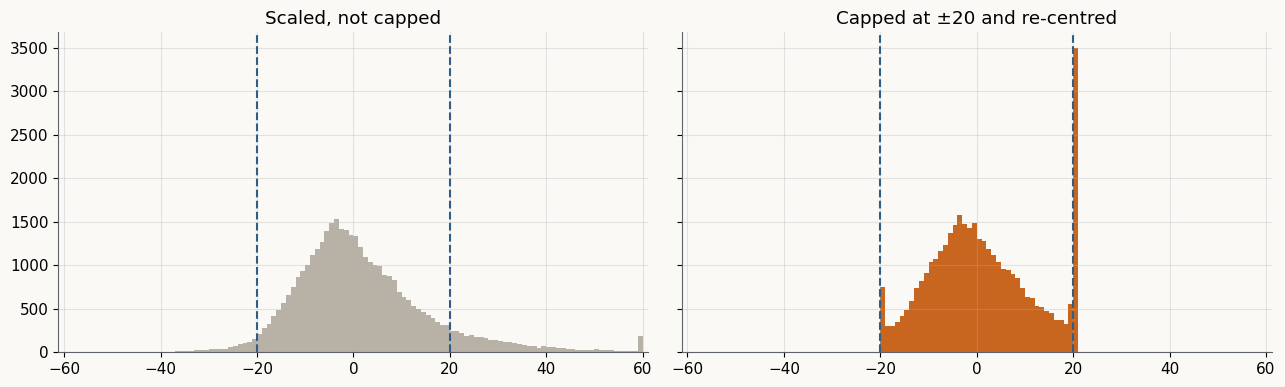

average |forecast| 8.8 ; share of forecasts at the cap 12 %


In [9]:
f_pre = cross_sectional_forecast(raw, M_PIT, cap=1e9)[0].where(M_PIT).stack().dropna()
f_post = FC_PIT.where(M_PIT).stack().dropna()
fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
bins = np.linspace(-60, 60, 121)
ax[0].hist(f_pre.clip(-60, 60), bins=bins, color=GREY); ax[0].set_title("Scaled, not capped")
ax[1].hist(f_post, bins=bins, color=ORANGE); ax[1].set_title("Capped at ±20 and re-centred")
for a in ax:
    a.axvline(-20, color=BLUE, ls="--"); a.axvline(20, color=BLUE, ls="--")
finish()
print(f"average |forecast| {f_post.abs().mean():.1f} ; share of forecasts at the cap {(f_post.abs() > 19.5).mean() * 100:.0f} %")

## 7. Twenty signals that live through time

The signal is not a verdict, it is a position that moves every day. Here are the 20 names that spent the most days in the universe over the last twelve months, and their forecast. Orange: long. Blue: short. Grey band: out of the universe, forecast 0.

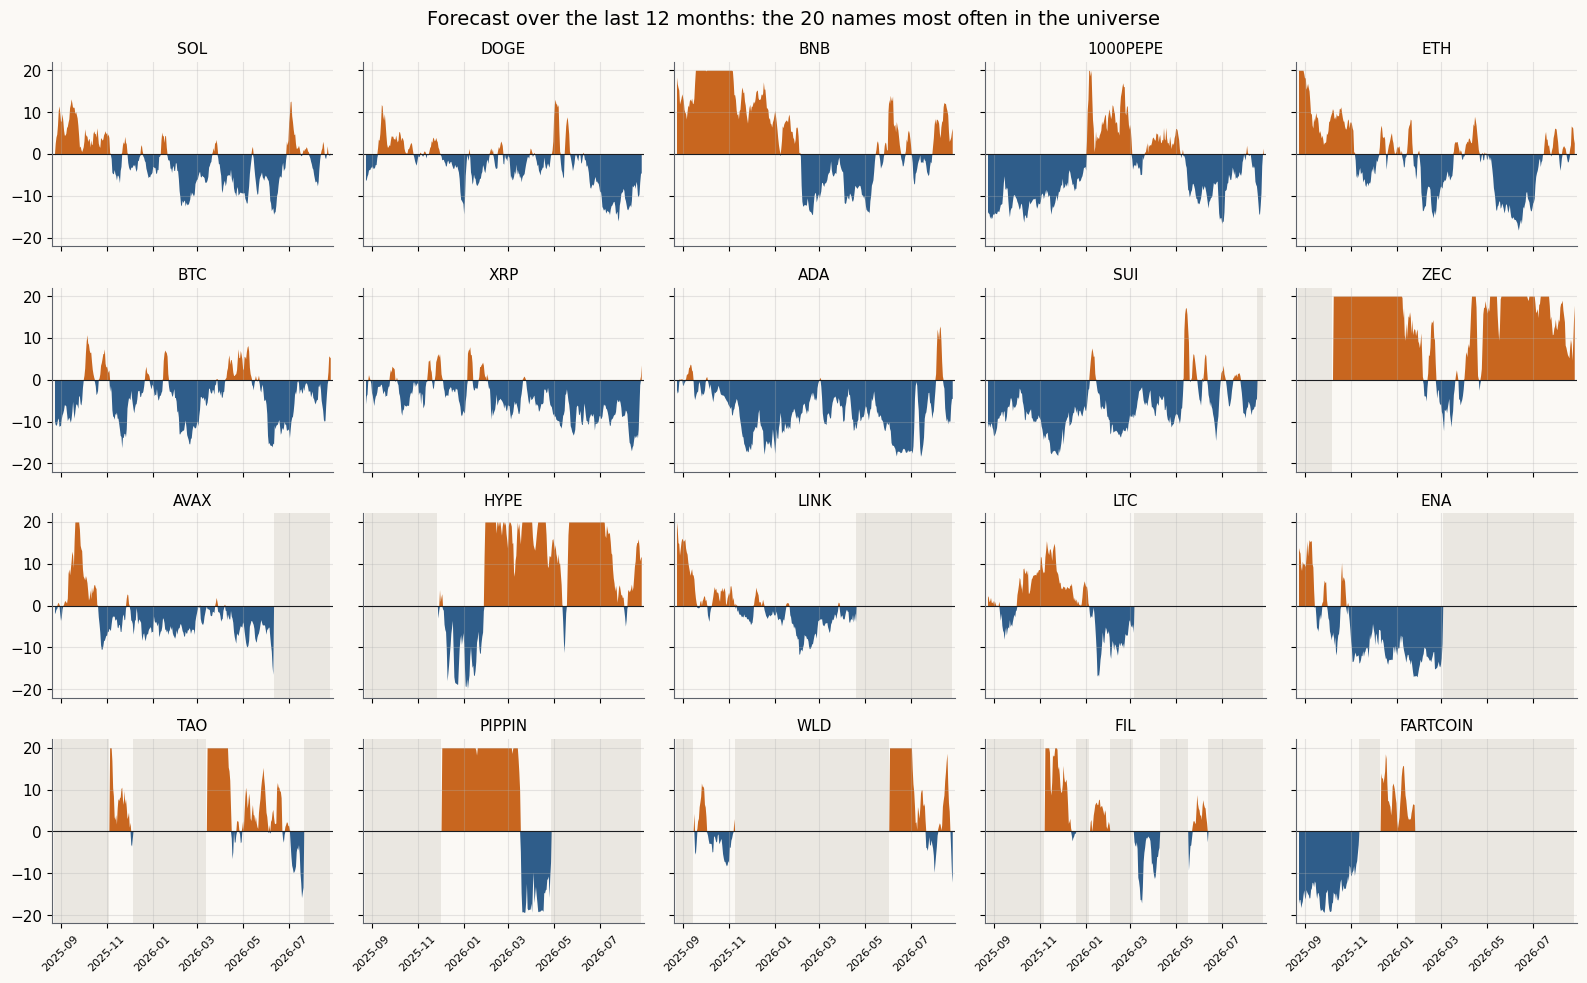

In [10]:
since = LAST - pd.Timedelta(days=365)
names = M_PIT.loc[since:].sum().sort_values(ascending=False).index[:20]
fig, axes = plt.subplots(4, 5, figsize=(16, 10), sharex=True, sharey=True)
for a, c in zip(axes.flat, names):
    f = FC_PIT[c].loc[since:].fillna(0.0)
    out = ~M_PIT[c].loc[since:]
    a.fill_between(f.index, 0, f.clip(lower=0), color=ORANGE, lw=0)
    a.fill_between(f.index, 0, f.clip(upper=0), color=BLUE, lw=0)
    a.fill_between(f.index, -22, 22, where=out, color=GREY, alpha=.25, lw=0)
    a.axhline(0, color=DARK, lw=.8); a.set_ylim(-22, 22); a.set_title(nm(c), fontsize=11)
    a.tick_params(axis="x", labelrotation=45, labelsize=8)
fig.suptitle("Forecast over the last 12 months: the 20 names most often in the universe", fontsize=14)
finish()

## 8. The book, week by week

Each frame is one week of the last year. Left: the forecast of every name in the universe that week, strongest at the top. Right: where the money goes (forecast ÷ volatility, as a share of the book). Watch names climb, fall, enter and leave, while the dollars long and short stay equal.

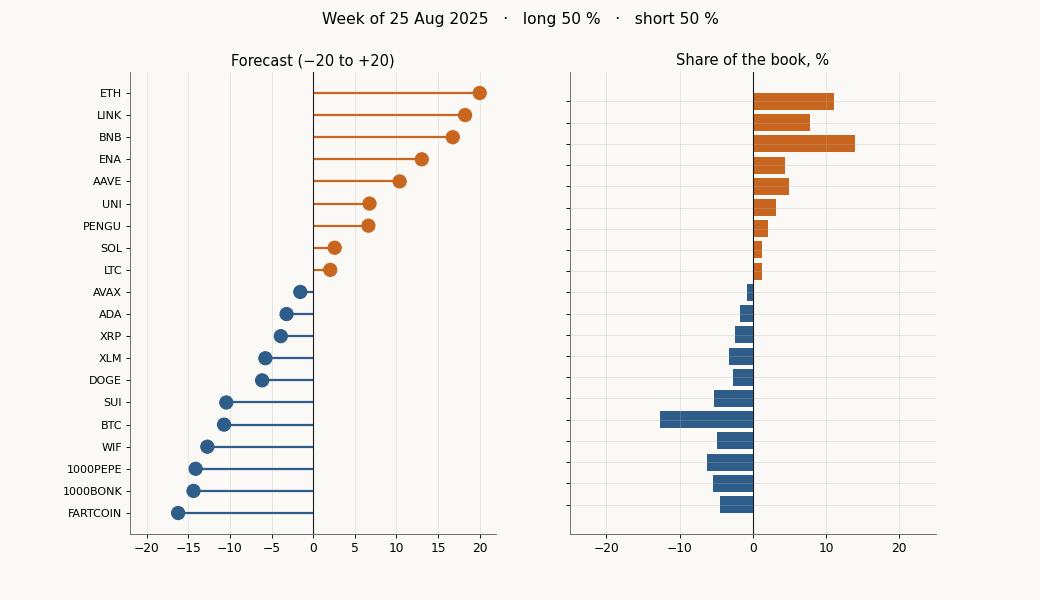

In [11]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image
import os
os.makedirs("figures", exist_ok=True)

dates = FC_PIT.loc[LAST - pd.Timedelta(days=364):].index[::7]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 7.5), width_ratios=[1, 1])

def frame(d):
    a1.clear(); a2.clear()
    m = M_PIT.loc[d][M_PIT.loc[d]].index
    f = FC_PIT.loc[d, m].sort_values()
    pos = f / VOL_A.loc[d, f.index]
    pos = pos / pos.abs().sum() * 100
    y = np.arange(len(f)); cols = np.where(f > 0, ORANGE, BLUE)
    a1.hlines(y, 0, f, color=cols, lw=2); a1.scatter(f, y, s=140, color=cols, zorder=3)
    a1.axvline(0, color=DARK, lw=1); a1.set_xlim(-22, 22); a1.set_yticks(y, [nm(c) for c in f.index], fontsize=10)
    a1.set_title("Forecast (−20 to +20)"); a1.grid(axis="y", alpha=0)
    a2.barh(y, pos, color=cols); a2.axvline(0, color=DARK, lw=1); a2.set_xlim(-25, 25)
    a2.set_yticks(y, [""] * len(y)); a2.set_title("Share of the book, %")
    lng, sht = pos[pos > 0].sum(), -pos[pos < 0].sum()
    fig.suptitle(f"Week of {d:%d %b %Y}   ·   long {lng:.0f} %   ·   short {sht:.0f} %", fontsize=14)

anim = FuncAnimation(fig, frame, frames=dates, interval=450)
anim.save("figures/signal_book.gif", writer=PillowWriter(fps=2.5), dpi=80)
plt.close(fig)
Image(filename="figures/signal_book.gif")

## What to take away from Part 1

- Each step fixes one visible problem.
- The output is not "buy these five coins": it is 20 positions that move every day, long and short in equal dollars.

# Part 2 · Lesson 2.6: from signal to dollars

## 9. Setup

The sizing code of notebook 02, section 4, plus two helpers for this part: `full_size` and `stats`.

In [12]:
BOOK = 1_000_000                # a $1M book, for the dollar examples

def buffered(target, full_size, f=BUFFER):
    """Only move when outside the band [target - f*full, target + f*full]. One name, one loop."""
    t, b = target.values, f * full_size.values
    out, cur = np.empty(len(t)), 0.0
    for i in range(len(t)):
        lo, hi = t[i] - b[i], t[i] + b[i]
        cur = lo if cur < lo else (hi if cur > hi else cur)
        out[i] = cur
    return pd.Series(out, index=target.index)

def full_size(W, idm=1.0):
    """One full size per name, in units of capital: target vol / coin vol x 1/n x IDM."""
    return (W / VOL_A).mul(idm, axis=0).mul(TARGET_VOL).reindex(FC_PIT.index).fillna(0.0)

def positions(FC, W, idm=1.0, f=BUFFER, max_lev=15.0):
    """Position in units of capital, per name: forecast/10 x full size, capped, buffered."""
    full = full_size(W, idm)
    target = (FC / 10 * full).clip(-max_lev * full, max_lev * full)
    return pd.DataFrame({c: buffered(target[c].fillna(0.0), full[c], f) for c in FC.columns})

def pnl(P, fee_bps=FEE_BPS):
    """Daily P&L: price return + funding collected - costs, position held = yesterday's."""
    held = P.shift(1)
    price = (held * PX.pct_change(fill_method=None)).fillna(0.0).sum(axis=1)
    fund  = (-held * FUND).fillna(0.0).sum(axis=1)
    cost  = (held.diff().abs() * fee_bps / 1e4).fillna(0.0).sum(axis=1)
    return pd.DataFrame({"price": price, "funding": fund, "cost": -cost, "total": price + fund - cost})

def expanding_idm(R, min_days=180, detail=False):
    """target / realised vol of the un-scaled strategy, on past years only, from its first trading day."""
    R = R.loc[R.ne(0).idxmax():]
    out, rows = pd.Series(1.0, index=R.index), []
    for y in sorted(set(R.index.year))[1:]:
        past = R[R.index.year < y]
        if len(past) >= min_days and past.std() > 0:
            vol = past.std() * np.sqrt(PPY)
            out[R.index.year == y] = min(TARGET_VOL / vol, np.sqrt(N_UNIVERSE))   # never more than sqrt(n)
            rows.append((y, len(past), vol * 100, TARGET_VOL / vol, out[R.index.year == y].iloc[0]))
    return (out, rows) if detail else out

def run(FC, W, fee_bps=FEE_BPS, f=BUFFER, use_idm=True):
    P0 = positions(FC, W, 1.0, f)
    idm = expanding_idm(pnl(P0, fee_bps)["total"]).reindex(FC.index).fillna(1.0) if use_idm else 1.0
    P = positions(FC, W, idm, f)
    R = pnl(P, fee_bps)
    start = P.abs().sum(axis=1).gt(0).idxmax()
    return P.loc[start:], R.loc[start:]

def stats(P, R):
    r = R["total"]
    return pd.Series({"Sharpe": r.mean() / r.std() * np.sqrt(PPY), "Vol %": r.std() * np.sqrt(PPY) * 100,
                      "Turnover x/yr": P.diff().abs().sum(axis=1).mean() * PPY, "Costs %": R["cost"].sum() * 100})
print("ready")

ready


## 10. From signal to dollars, on one real day

Budget per coin = book ÷ number of coins. Vol ratio = 20 % ÷ the coin's vol. Full size = budget × vol ratio. Position = full size × signal ÷ 10. Before the IDM.

Bitcoin on 24 August 2026: budget $50,000  x vol ratio 0.39 (20 % / 52 %)  = full size $19,403  x signal +5.3 / 10  = $+10,206
         vol % signal budget $ vol ratio full size $ position $
WLD        108  -12.2   50,000      0.19       9,275    -11,270
COTI       188  -18.0   50,000      0.11       5,327     -9,603
BANK       255  -19.9   50,000      0.08       3,921     -7,802
DEXE       303  -20.0   50,000      0.07       3,302     -6,604
BEAT       354  -20.0   50,000      0.06       2,827     -5,654
CYS        357  -20.0   50,000      0.06       2,803     -5,605
ADA         89   -4.5   50,000      0.22      11,235     -5,095
DOGE        90   -4.5   50,000      0.22      11,145     -4,970
BLESS      490  -10.9   50,000      0.04       2,041     -2,218
AKE        427   -7.5   50,000      0.05       2,342     -1,756
ACE        400   -3.0   50,000      0.05       2,502       -761
SOL         72   +0.2   50,000      0.28      13,957       +340
1000PEPE   136   +1.4   50,000      0.15 

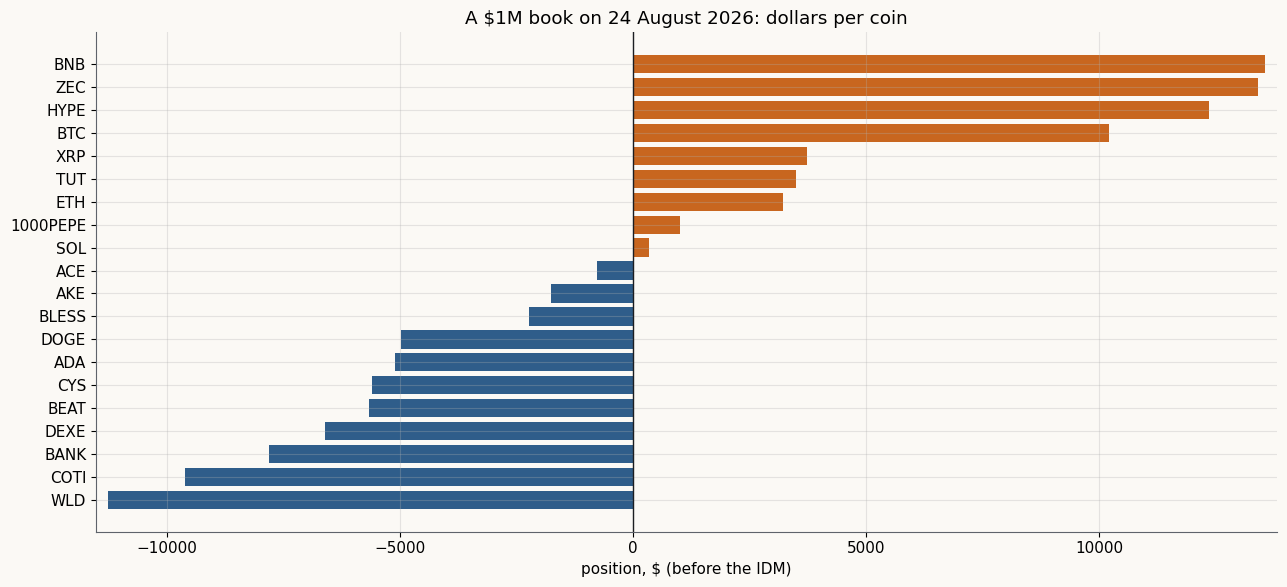

In [13]:
d = LAST
m = M_PIT.loc[d][M_PIT.loc[d]].index
t = pd.DataFrame({"vol %": VOL_A.loc[d, m] * 100, "signal": FC_PIT.loc[d, m]})
t["budget $"] = BOOK / len(m)
t["vol ratio"] = TARGET_VOL / VOL_A.loc[d, m]
t["full size $"] = t["budget $"] * t["vol ratio"]
t["position $"] = t["full size $"] * t["signal"] / 10
t.index = [nm(c) for c in t.index]
t = t.sort_values("position $")

b = t.loc["BTC"]
print(f"Bitcoin on {d:%d %B %Y}: budget ${b['budget $']:,.0f}  x vol ratio {b['vol ratio']:.2f} (20 % / {b['vol %']:.0f} %)"
      f"  = full size ${b['full size $']:,.0f}  x signal {b['signal']:+.1f} / 10  = ${b['position $']:+,.0f}")
print(t.to_string(formatters={"vol %": "{:.0f}".format, "signal": "{:+.1f}".format, "budget $": "{:,.0f}".format,
                                "vol ratio": "{:.2f}".format, "full size $": "{:,.0f}".format, "position $": "{:+,.0f}".format}))

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(t.index, t["position $"], color=np.where(t["position $"] > 0, ORANGE, BLUE))
ax.axvline(0, color=DARK, lw=1); ax.set_xlabel("position, $ (before the IDM)")
ax.set_title(f"A $1M book on {d:%d %B %Y}: dollars per coin"); plt.tight_layout(); plt.show()

## 11. Inverse vol: a calm coin gets more dollars

Bitcoin and PEPE since 2023. Top: their annual volatility. Bottom: the full size each one gets in a $1M book. When a coin gets wilder, its full size shrinks: the risk per coin stays the same.

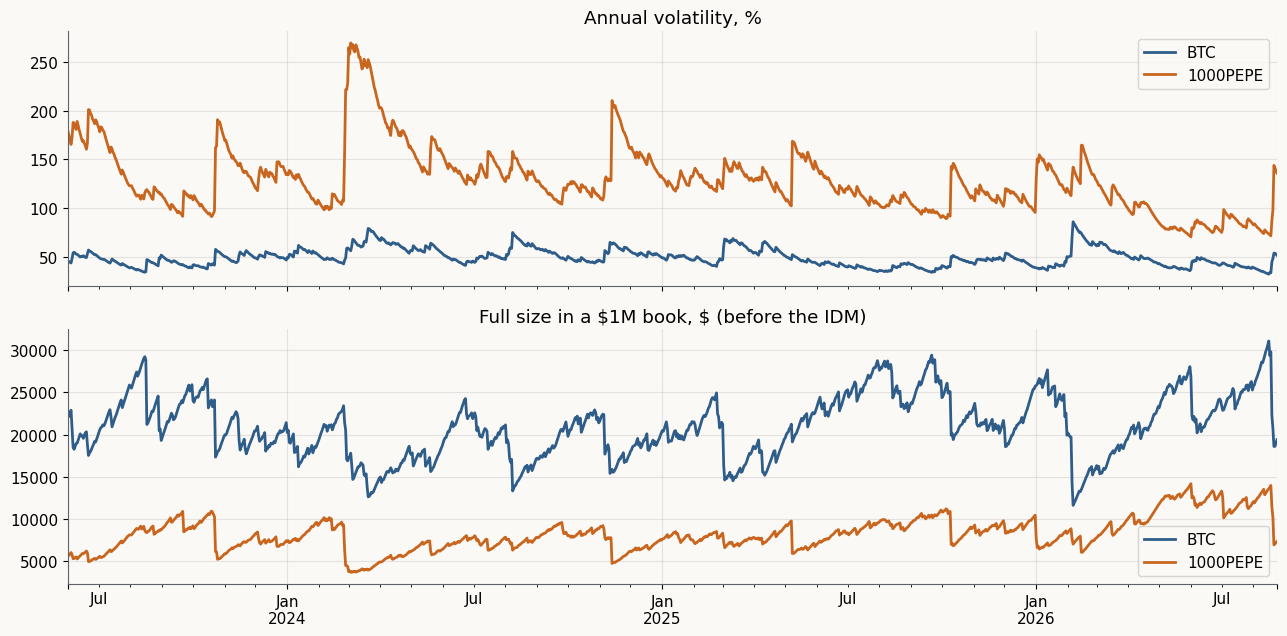

In [14]:
A, B = "BTCUSDT", "1000PEPEUSDT"
since = "2023-06-01"
fig, ax = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
for c, col in ((A, BLUE), (B, ORANGE)):
    (VOL_A[c].loc[since:] * 100).plot(ax=ax[0], color=col, lw=2, label=nm(c))
    (BOOK / N_UNIVERSE * TARGET_VOL / VOL_A[c].loc[since:]).plot(ax=ax[1], color=col, lw=2, label=nm(c))
ax[0].set_title("Annual volatility, %"); ax[0].legend()
ax[1].set_title("Full size in a \\$1M book, \\$ (before the IDM)"); ax[1].legend()
finish()

## 12. Without the IDM: how much does the strategy really move?

The whole strategy with IDM = 1, and its volatility over a rolling year. We asked for 20 %.

Why so low: each coin carries about 1 % of risk, and twenty bets of 1 % only make 20 % if they all move together. We measure ρ, the average correlation between the positions' P&L, and check the rule: strategy vol = σ × √(n × (1 + (n − 1) × ρ)).

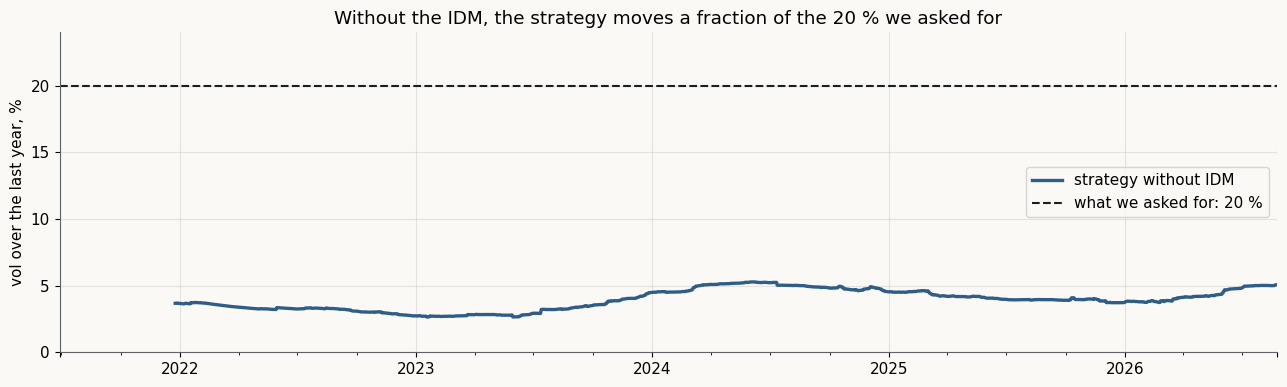

volatility without IDM, whole sample: 4.1 %
last year, 10 coins held almost every day: each position moves 0.86 % a year on average
average correlation between their P&L (rho): 0.136
the rule predicts 4.0 % for the strategy ; measured: 3.5 %


In [15]:
P1, R1 = run(FC_PIT, W_PIT, use_idm=False)
roll1 = R1["total"].rolling(PPY, min_periods=180).std() * np.sqrt(PPY) * 100
fig, ax = plt.subplots(figsize=(13, 4))
roll1.plot(ax=ax, color=BLUE, lw=2.4, label="strategy without IDM")
ax.axhline(20, color=DARK, ls="--", lw=1.5, label="what we asked for: 20 %")
ax.set_ylim(0, 24); ax.set_ylabel("vol over the last year, %"); ax.legend()
ax.set_title("Without the IDM, the strategy moves a fraction of the 20 % we asked for"); ax.set_xlabel("")
plt.tight_layout(); plt.show()
print(f"volatility without IDM, whole sample: {R1['total'].std() * np.sqrt(PPY) * 100:.1f} %")

# the why: rho between the positions' P&L, last year
last = P1.index[-1] - pd.Timedelta(days=365)
X = (P1.shift(1) * PX.pct_change(fill_method=None)).loc[last:].fillna(0.0)
X = X.loc[:, (X != 0).sum() > 300]
CM = X.corr().values; n = CM.shape[0]
rho_pos = (CM.sum() - n) / (n * (n - 1))
sig = X.std().mean() * np.sqrt(PPY)
pred = sig * np.sqrt(n * (1 + (n - 1) * rho_pos))
meas = X.sum(axis=1).std() * np.sqrt(PPY)
print(f"last year, {n} coins held almost every day: each position moves {sig * 100:.2f} % a year on average")
print(f"average correlation between their P&L (rho): {rho_pos:.3f}")
print(f"the rule predicts {pred * 100:.1f} % for the strategy ; measured: {meas * 100:.1f} %")

## 13. The IDM: measured every 1 January, on the past only

The IDM of each year, then the rolling volatility with and without it. The orange line climbs through 2022 only because its rolling year still contains 2021, run at IDM 1.

,past days used,vol without IDM %,20 % / vol,IDM used
year traded,,,,
2022,186,3.67,5.44,4.47
2023,551,3.09,6.48,4.47
2024,916,3.71,5.40,4.47
2025,1282,3.96,5.05,4.47
2026,1647,3.91,5.11,4.47


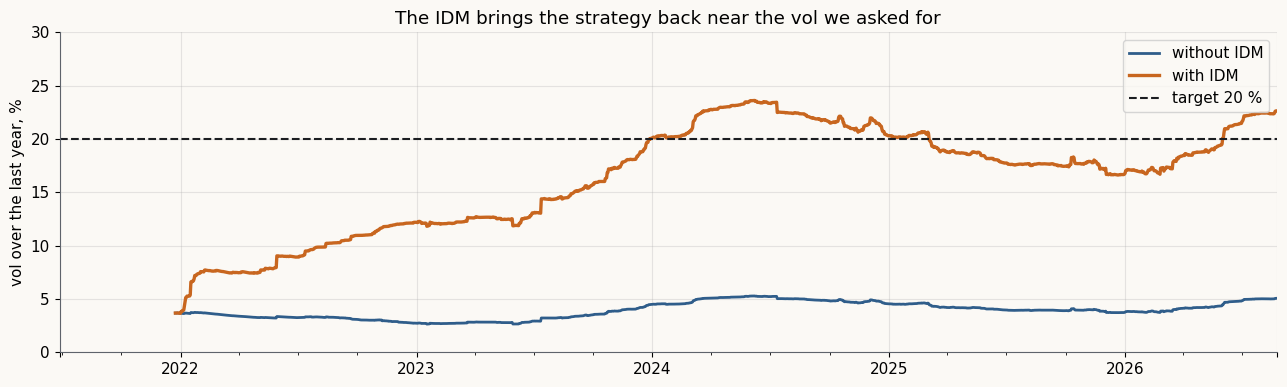

volatility with IDM, whole sample: 17.8 %


In [16]:
idm, rows = expanding_idm(pnl(positions(FC_PIT, W_PIT, 1.0))["total"], detail=True)
tab = pd.DataFrame(rows, columns=["year traded", "past days used", "vol without IDM %", "20 % / vol", "IDM used"]).set_index("year traded")
display(tab.round(2))

P2, R2 = run(FC_PIT, W_PIT)
roll2 = R2["total"].rolling(PPY, min_periods=180).std() * np.sqrt(PPY) * 100
fig, ax = plt.subplots(figsize=(13, 4))
roll1.plot(ax=ax, color=BLUE, lw=2, label="without IDM")
roll2.plot(ax=ax, color=ORANGE, lw=2.4, label="with IDM")
ax.axhline(20, color=DARK, ls="--", lw=1.5, label="target 20 %")
ax.set_ylim(0, 30); ax.set_ylabel("vol over the last year, %"); ax.legend(); ax.set_xlabel("")
ax.set_title("The IDM brings the strategy back near the vol we asked for"); plt.tight_layout(); plt.show()
print(f"volatility with IDM, whole sample: {R2['total'].std() * np.sqrt(PPY) * 100:.1f} %")

## 14. The buffer: when do we actually trade?

SOL over its last 90 days in the universe. Dashed: the ideal position (signal ÷ 10 × full size). Shaded: the band, ± 10 % of the full size. Black: what we hold. Orange dots: the days we trade.

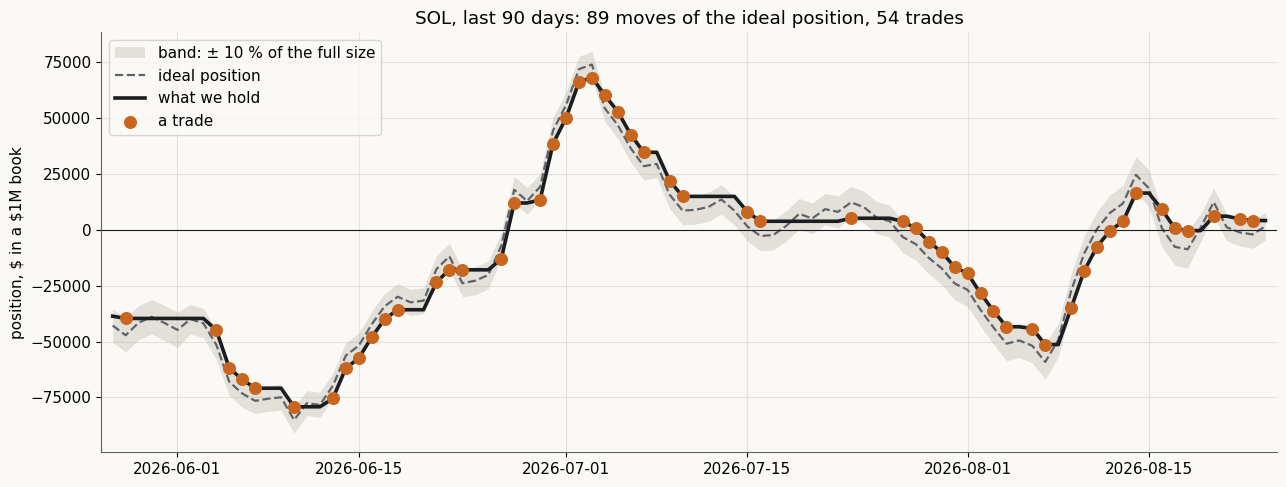

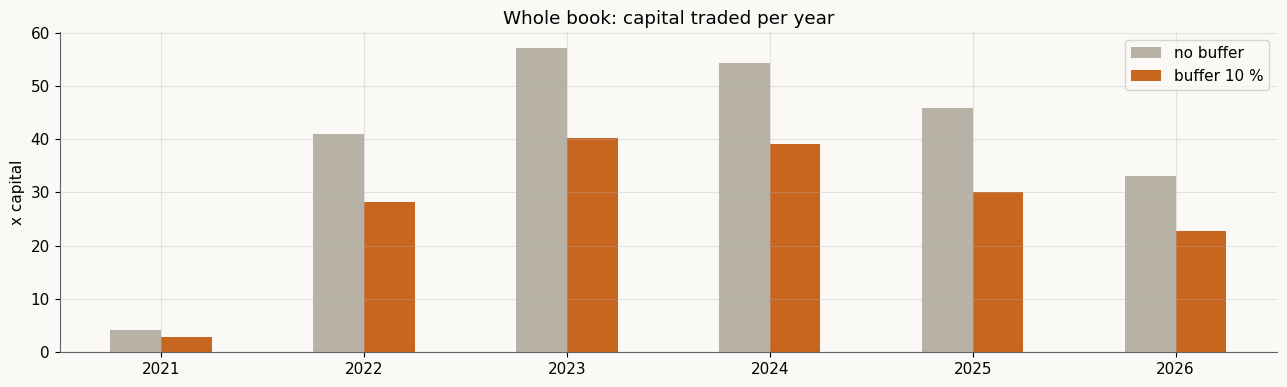

In [17]:
C = "SOLUSDT"
idm_s = expanding_idm(pnl(positions(FC_PIT, W_PIT, 1.0))["total"]).reindex(FC_PIT.index).fillna(1.0)
full = full_size(W_PIT, idm_s)[C]
ideal = (FC_PIT[C] / 10 * full).fillna(0.0)
held = buffered(ideal, full)
days = M_PIT[C][M_PIT[C]].index[-90:]
i_, h_, f_ = ideal.loc[days] * BOOK, held.loc[days] * BOOK, full.loc[days] * BOOK * BUFFER
trades = h_.diff().abs() > 1

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(days, i_ - f_, i_ + f_, color=GREY, alpha=.35, lw=0, label="band: ± 10 % of the full size")
ax.plot(days, i_, color="#5e636b", ls="--", lw=1.6, label="ideal position")
ax.plot(days, h_, color=DARK, lw=2.6, label="what we hold")
ax.scatter(days[trades.values], h_[trades], s=70, color=ORANGE, zorder=3, label="a trade")
ax.axhline(0, color=DARK, lw=.8); ax.set_ylabel("position, \\$ in a \\$1M book"); ax.legend(loc="upper left")
ax.set_title(f"{nm(C)}, last 90 days: {int((i_.diff().abs() > 1).sum())} moves of the ideal position, {int(trades.sum())} trades")
plt.tight_layout(); plt.show()

Pb, Rb = run(FC_PIT, W_PIT, f=0.0)
tov = pd.DataFrame({"no buffer": Pb.diff().abs().sum(axis=1).resample("YE").sum(),
                    "buffer 10 %": P2.diff().abs().sum(axis=1).resample("YE").sum()})
tov.index = tov.index.year
ax = tov.plot.bar(figsize=(13, 4), color=[GREY, ORANGE], rot=0)
ax.set_title("Whole book: capital traded per year"); ax.set_ylabel("x capital"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 15. What each brick changes

Three versions, same signal, same costs. The IDM changes the size (the vol). The buffer changes the costs.

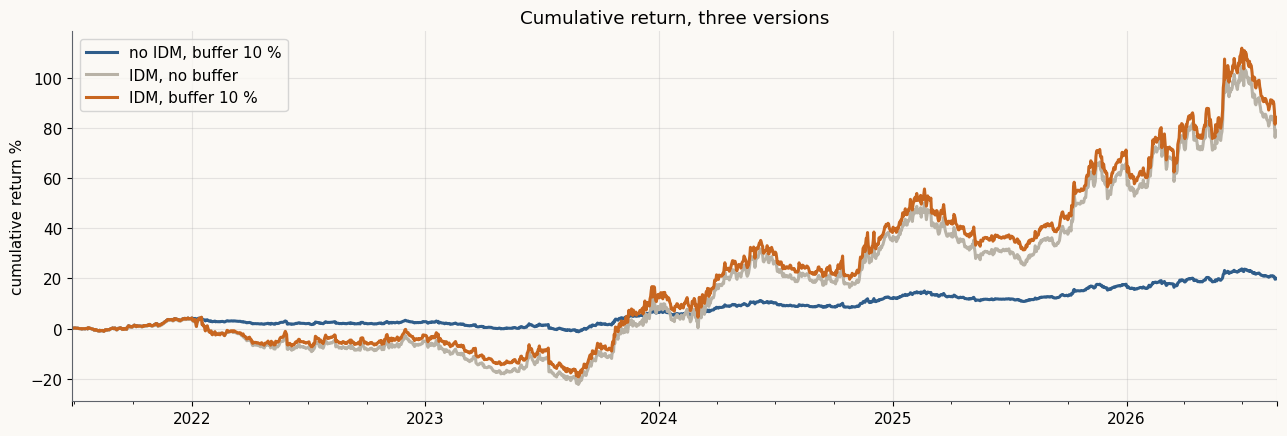

,Sharpe,Vol %,Turnover x/yr,Costs %
"no IDM, buffer 10 %",0.87,4.15,7.49,-1.94
"IDM, no buffer",0.70,18.20,45.62,-11.77
"IDM, buffer 10 %",0.74,17.84,31.62,-8.16


In [18]:
runs = {"no IDM, buffer 10 %": (P1, R1), "IDM, no buffer": (Pb, Rb), "IDM, buffer 10 %": (P2, R2)}
start = max(R.index[0] for _, R in runs.values())
fig, ax = plt.subplots(figsize=(13, 4.5))
for (k, (P, R)), col in zip(runs.items(), (BLUE, GREY, ORANGE)):
    (((1 + R["total"].loc[start:]).cumprod() - 1) * 100).plot(ax=ax, color=col, lw=2.2, label=k)
ax.set_ylabel("cumulative return %"); ax.legend(); ax.set_xlabel(""); ax.set_title("Cumulative return, three versions")
plt.tight_layout(); plt.show()
display(pd.DataFrame({k: stats(P, R) for k, (P, R) in runs.items()}).T.round(2))

## What to take away from Part 2

- A forecast of 10 is one full size, and the full size follows the vol: a calm coin gets more dollars.
- Twenty positions of 1 % risk do not add up to 20 %. The IDM measures the gap on the past only and scales back.
- The buffer decides when you trade. It cuts the costs, not the edge.

# Part 3 · Lesson 2.7: reading the backtest

The strategy of notebook 02 (IDM, buffer 10 %, 5 bp). Every number of the diagnostic, by hand. The Sharpe comes last.

In [19]:
P, R = P2, R2
r = R["total"]
years = len(r) / PPY
print(f"{r.index[0]:%Y-%m-%d} -> {r.index[-1]:%Y-%m-%d}: {len(r)} days, {years:.1f} years")

2021-06-28 -> 2026-08-24: 1884 days, 5.2 years


## 16. Where the money comes from

Three columns, never summed too early: price (yesterday's position × today's return), funding (a long pays it, a short collects it), costs.

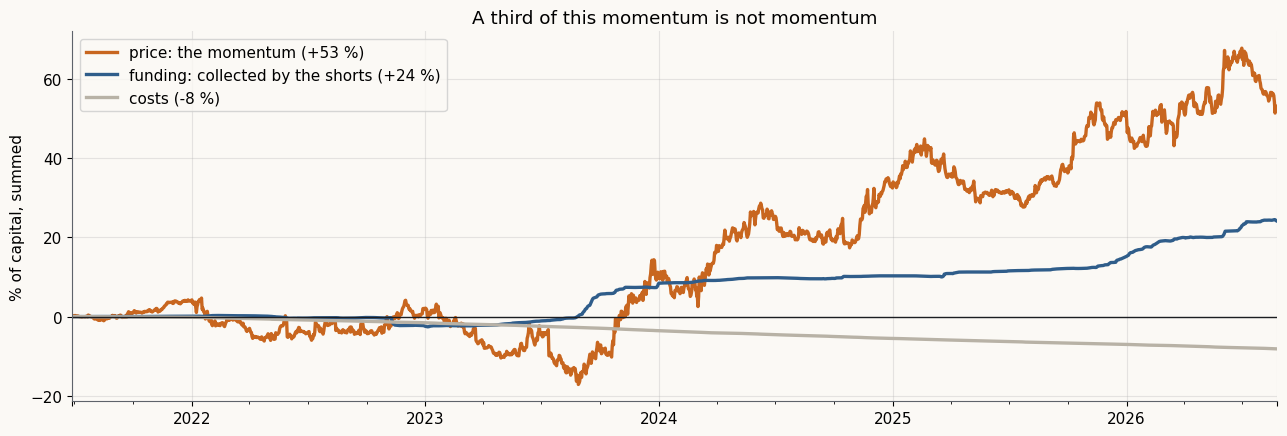

funding share of the gross P&L: 31 %


In [20]:
cum = R[["price", "funding", "cost"]].cumsum() * 100
fig, ax = plt.subplots(figsize=(13, 4.5))
for c, col, lab in (("price", ORANGE, "price: the momentum"), ("funding", BLUE, "funding: collected by the shorts"), ("cost", GREY, "costs")):
    cum[c].plot(ax=ax, color=col, lw=2.4, label=f"{lab} ({cum[c].iloc[-1]:+.0f} %)")
ax.axhline(0, color=DARK, lw=1); ax.set_ylabel("% of capital, summed"); ax.legend(); ax.set_xlabel("")
ax.set_title("A third of this momentum is not momentum"); plt.tight_layout(); plt.show()
gross = R["price"].sum() + R["funding"].sum()
print(f"funding share of the gross P&L: {R['funding'].sum() / gross * 100:.0f} %")

## 17. Turnover, and what it costs

Turnover = capital traded in a year. Each unit traded pays 5 bp, so the yearly cost is turnover × 5 bp. Checked against the cost column.

turnover: 31.6 x capital a year
by hand : 31.6 x 5 bp = 1.58 % of capital a year
measured: 1.58 % a year (cost column / 5.2 years)


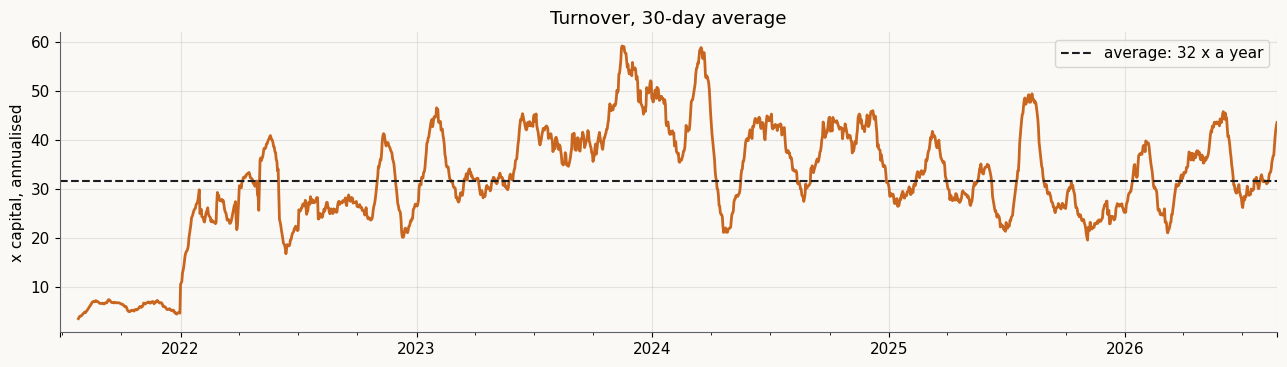

In [21]:
traded = P.diff().abs().sum(axis=1)
turnover = traded.mean() * PPY
print(f"turnover: {turnover:.1f} x capital a year")
print(f"by hand : {turnover:.1f} x 5 bp = {turnover * FEE_BPS / 100:.2f} % of capital a year")
print(f"measured: {-R['cost'].sum() / years * 100:.2f} % a year (cost column / {years:.1f} years)")

fig, ax = plt.subplots(figsize=(13, 3.8))
(traded.rolling(30).mean() * PPY).plot(ax=ax, color=ORANGE, lw=2)
ax.axhline(turnover, color=DARK, ls="--", lw=1.5, label=f"average: {turnover:.0f} x a year")
ax.set_ylabel("x capital, annualised"); ax.legend(); ax.set_xlabel("")
ax.set_title("Turnover, 30-day average"); plt.tight_layout(); plt.show()

## 18. Breakeven cost

The cost per unit traded at which the net return is zero: gross P&L ÷ capital traded.

breakeven: 47 bp ; we assume 5 bp, about 9 times less


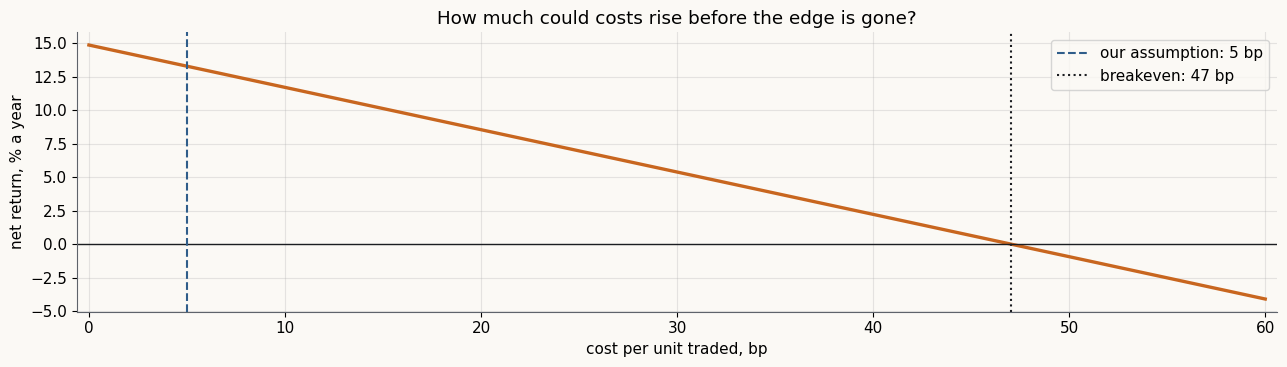

In [22]:
breakeven = gross / traded.sum() * 1e4
print(f"breakeven: {breakeven:.0f} bp ; we assume {FEE_BPS:.0f} bp, about {breakeven / FEE_BPS:.0f} times less")
bps = np.arange(0, 61, 1)
net = [(gross - traded.sum() * b / 1e4) / years * 100 for b in bps]
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(bps, net, color=ORANGE, lw=2.4); ax.axhline(0, color=DARK, lw=1)
ax.axvline(FEE_BPS, color=BLUE, ls="--", label=f"our assumption: {FEE_BPS:.0f} bp")
ax.axvline(breakeven, color=DARK, ls=":", label=f"breakeven: {breakeven:.0f} bp")
ax.set_xlabel("cost per unit traded, bp"); ax.set_ylabel("net return, % a year"); ax.legend()
ax.set_title("How much could costs rise before the edge is gone?"); plt.tight_layout(); plt.show()

## 19. The range: a block bootstrap

Cut the daily returns in 63-day blocks, draw them at random into a new history of the same length, recompute. 2,000 times.

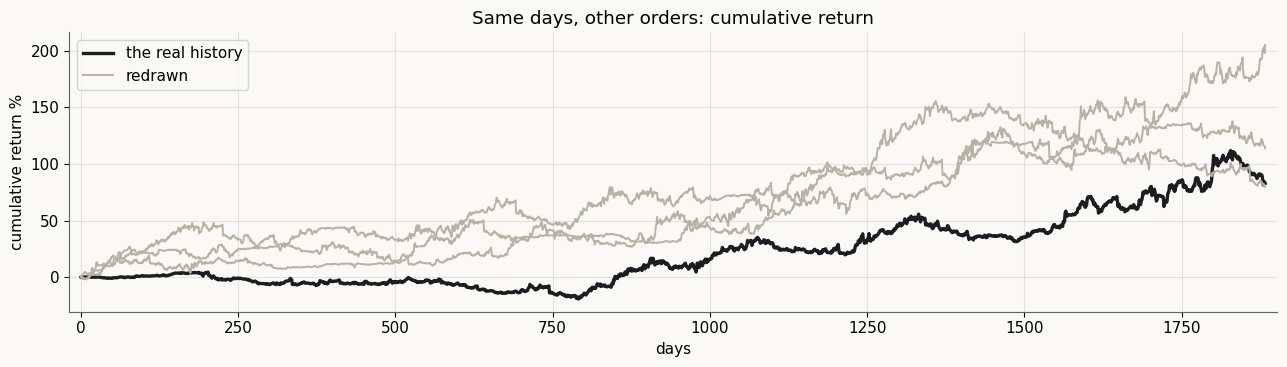

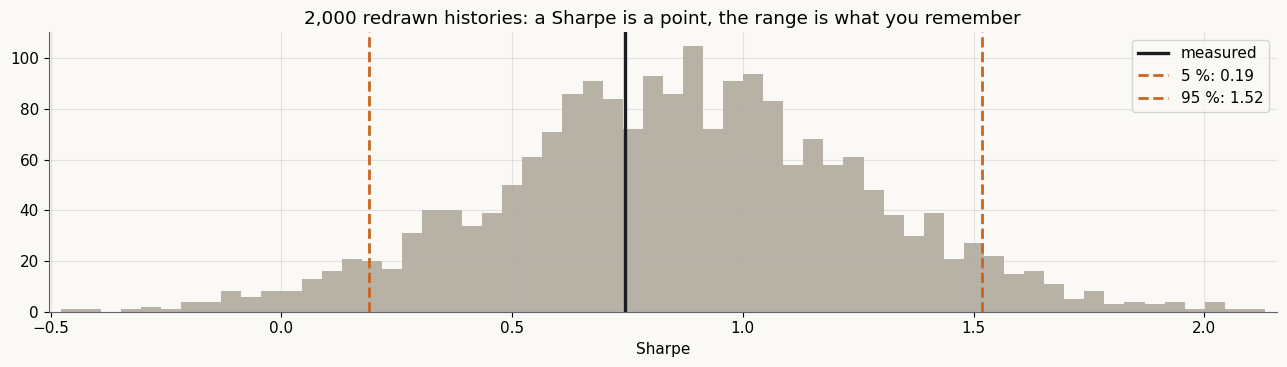

In [23]:
def resample(a, block=63, rng=None):
    starts = rng.integers(0, len(a) - block, len(a) // block + 1)
    return np.concatenate([a[i:i + block] for i in starts])[:len(a)]

rng = np.random.default_rng(0)
a = r.values
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot((np.cumprod(1 + a) - 1) * 100, color=DARK, lw=2.4, label="the real history")
for k in range(3):
    ax.plot((np.cumprod(1 + resample(a, rng=rng)) - 1) * 100, color=GREY, lw=1.4, label="redrawn" if k == 0 else None)
ax.set_ylabel("cumulative return %"); ax.set_xlabel("days"); ax.legend(); ax.set_title("Same days, other orders: cumulative return")
plt.tight_layout(); plt.show()

rng = np.random.default_rng(0)
sh = []
for _ in range(2000):
    s = resample(a, rng=rng); sh.append(s.mean() / s.std() * np.sqrt(PPY))
sh = np.array(sh); lo, hi = np.percentile(sh, [5, 95])
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.hist(sh, bins=60, color=GREY)
ax.axvline(r.mean() / r.std() * np.sqrt(PPY), color=DARK, lw=2.4, label="measured")
ax.axvline(lo, color=ORANGE, ls="--", lw=2, label=f"5 %: {lo:.2f}"); ax.axvline(hi, color=ORANGE, ls="--", lw=2, label=f"95 %: {hi:.2f}")
ax.set_xlabel("Sharpe"); ax.legend(); ax.set_title("2,000 redrawn histories: a Sharpe is a point, the range is what you remember")
plt.tight_layout(); plt.show()

## 20. Return, vol and drawdown

The exit criterion of Pass 1 cuts at 1.5 × the worst drawdown.

CAGR 12.4 % at a vol of 17.8 % ; max drawdown -22.8 % on 2023-08-28


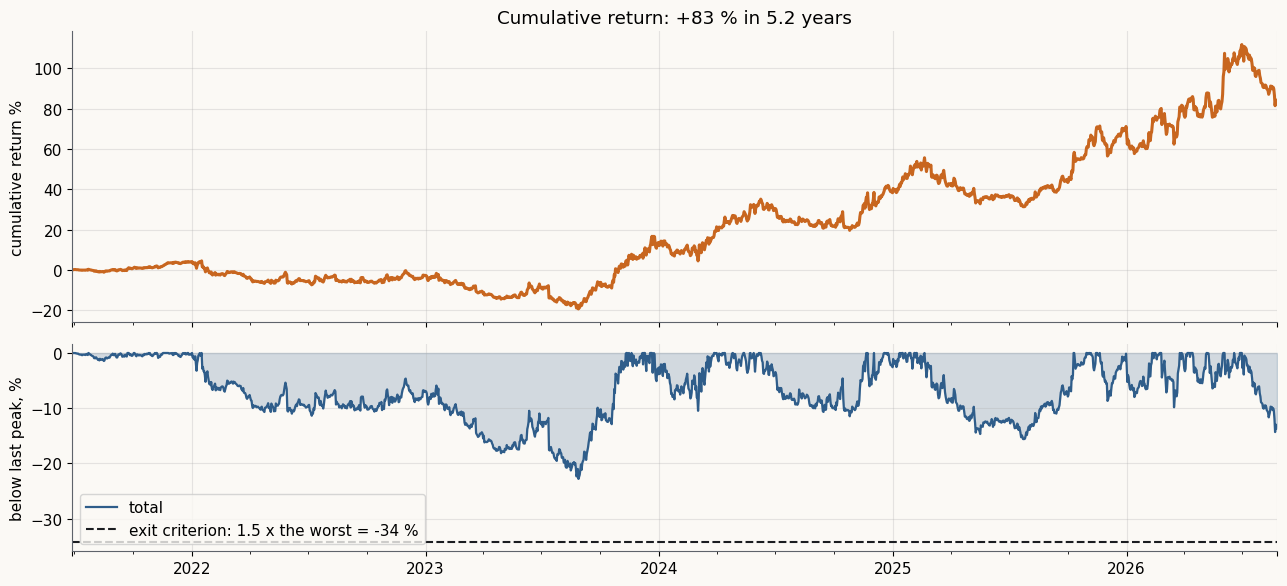

In [24]:
eq = (1 + r).cumprod()
dd = eq / eq.cummax() - 1
cagr = eq.iloc[-1] ** (1 / years) - 1
vol = r.std() * np.sqrt(PPY)
print(f"CAGR {cagr * 100:.1f} % at a vol of {vol * 100:.1f} % ; max drawdown {dd.min() * 100:.1f} % on {dd.idxmin():%Y-%m-%d}")
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True, height_ratios=[1.4, 1])
((eq - 1) * 100).plot(ax=ax[0], color=ORANGE, lw=2.2); ax[0].set_ylabel("cumulative return %"); ax[0].set_title(f"Cumulative return: {(eq.iloc[-1] - 1) * 100:+.0f} % in {years:.1f} years")
(dd * 100).plot(ax=ax[1], color=BLUE, lw=1.6); ax[1].fill_between(dd.index, dd * 100, 0, color=BLUE, alpha=.2)
ax[1].axhline(dd.min() * 150, color=DARK, ls="--", lw=1.5, label=f"exit criterion: 1.5 x the worst = {dd.min() * 150:.0f} %")
ax[1].set_ylabel("below last peak, %"); ax[1].legend(loc="lower left")
finish()

## 21. The t-stat

Mean ÷ std × √days, the same as Sharpe × √years. Below 2: not much shown. It grows with time, not with skill.

t-stat = mean / std x sqrt(1884 days) = 1.69
       = Sharpe 0.74 x sqrt(5.2 years) = 1.69


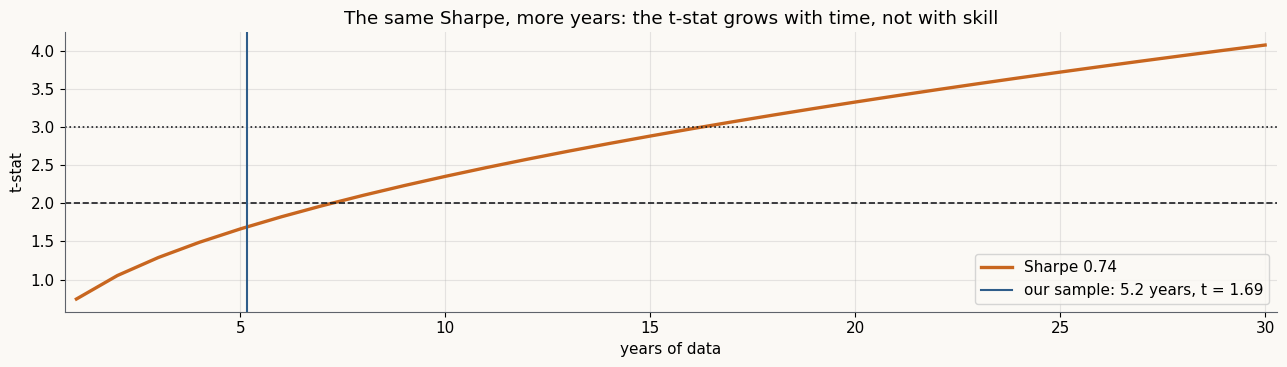

In [25]:
sharpe = r.mean() / r.std() * np.sqrt(PPY)
t = r.mean() / r.std() * np.sqrt(len(r))
print(f"t-stat = mean / std x sqrt({len(r)} days) = {t:.2f}")
print(f"       = Sharpe {sharpe:.2f} x sqrt({years:.1f} years) = {sharpe * np.sqrt(years):.2f}")
yrs = np.arange(1, 31)
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(yrs, sharpe * np.sqrt(yrs), color=ORANGE, lw=2.4, label=f"Sharpe {sharpe:.2f}")
ax.axhline(2, color=DARK, ls="--", lw=1.2); ax.axhline(3, color=DARK, ls=":", lw=1.2)
ax.axvline(years, color=BLUE, lw=1.5, label=f"our sample: {years:.1f} years, t = {t:.2f}")
ax.set_xlabel("years of data"); ax.set_ylabel("t-stat"); ax.legend()
ax.set_title("The same Sharpe, more years: the t-stat grows with time, not with skill"); plt.tight_layout(); plt.show()

## 22. And now, the Sharpe

In [26]:
print(pd.Series({"Sharpe": sharpe, "range 5 %": lo, "range 95 %": hi, "t-stat": t, "CAGR %": cagr * 100, "Vol %": vol * 100,
                 "Max drawdown %": dd.min() * 100, "Turnover x/yr": turnover, "Breakeven bp": breakeven,
                 "Funding share %": R["funding"].sum() / gross * 100}).round(2).to_string())

Sharpe              0.74
range 5 %           0.19
range 95 %          1.52
t-stat              1.69
CAGR %             12.41
Vol %              17.84
Max drawdown %    -22.80
Turnover x/yr      31.62
Breakeven bp       47.03
Funding share %    31.45


## What to take away from Part 3

- P&L split, turnover and breakeven first: is it what you think, and can you trade it?
- A Sharpe is one draw. Remember the range.
- A real but modest edge, a third of it carry, tradable at these costs, with a range that includes "barely anything".

# Part 4 · Lesson 2.8: when it works, when it breaks

Pass 1: works when coins go to different places (dispersion), suffers when everything moves together. We measure dispersion, then check how strong the link really is.

## 23. Measuring dispersion, on three real days

Every day, the standard deviation of the 20 coins' daily returns. Small: they move together, nothing to rank. Large: they go to different places. Each dot is one coin.

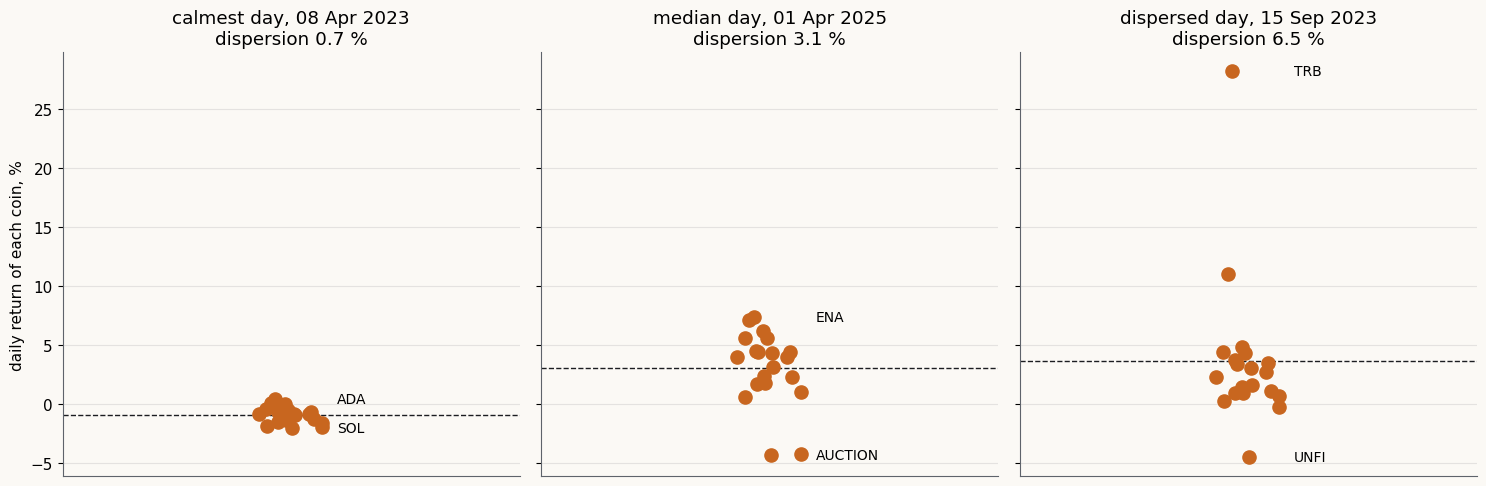

daily dispersion over the sample: 10 % of days below 1.8 %, median 3.1 %, 10 % above 6.5 %


In [27]:
RET = PX.pct_change(fill_method=None).where(M_PIT)          # daily returns, universe members only
DISP_D = RET.std(axis=1)                                      # dispersion, every day
live = DISP_D.loc[R2.index[0]:]
days = {"calmest day": live.idxmin(), "median day": (live - live.median()).abs().idxmin(),
        "dispersed day": (live - live.quantile(0.9)).abs().idxmin()}
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for a, (lab, d) in zip(ax, days.items()):
    r_ = (RET.loc[d].dropna() * 100).sort_values()
    a.scatter(np.zeros(len(r_)) + np.random.default_rng(1).uniform(-.15, .15, len(r_)), r_, s=90, color=ORANGE, zorder=3)
    for k in (r_.index[0], r_.index[-1]):
        a.annotate(nm(k), (0.2, r_[k]), fontsize=10, va="center")
    a.axhline(r_.mean(), color=DARK, ls="--", lw=1)
    a.set_xlim(-1, 1); a.set_xticks([]); a.set_title(f"{lab}, {d:%d %b %Y}\ndispersion {r_.std():.1f} %")
ax[0].set_ylabel("daily return of each coin, %"); plt.tight_layout(); plt.show()
print(f"daily dispersion over the sample: 10 % of days below {live.quantile(.1) * 100:.1f} %, median {live.median() * 100:.1f} %, 10 % above {live.quantile(.9) * 100:.1f} %")

## 24. Dispersion through time

The daily number is noisy: we average it by month. Dashed: the median month.

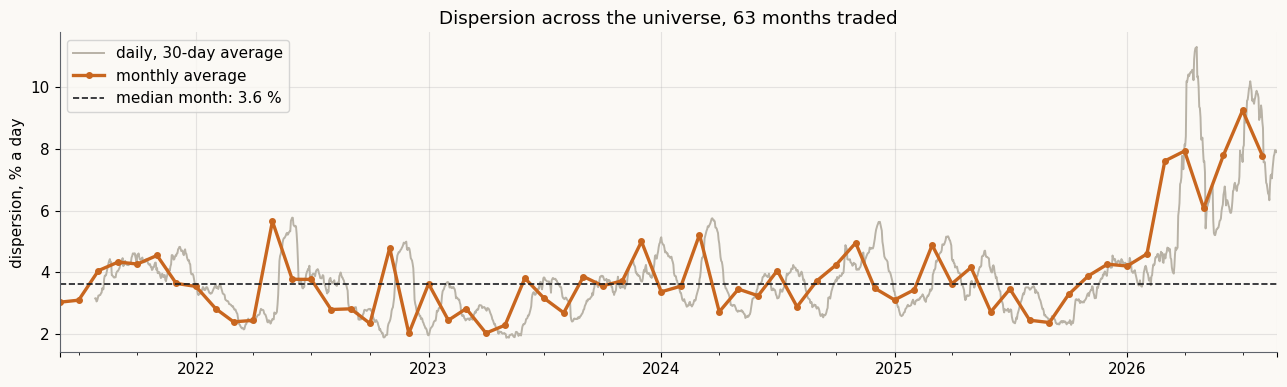

In [28]:
RM = R2[["total", "price", "funding"]].resample("ME").sum() * 100    # monthly P&L, %
DISP_M = (DISP_D.resample("ME").mean() * 100).reindex(RM.index)       # monthly dispersion, % a day, traded months only
fig, ax = plt.subplots(figsize=(13, 4))
(DISP_D.loc[R2.index[0]:] * 100).rolling(30).mean().plot(ax=ax, color=GREY, lw=1.4, label="daily, 30-day average")
DISP_M.plot(ax=ax, color=ORANGE, lw=2.4, marker="o", ms=4, label="monthly average")
ax.axhline(DISP_M.median(), color=DARK, ls="--", lw=1.2, label=f"median month: {DISP_M.median():.1f} %")
ax.set_ylabel("dispersion, % a day"); ax.legend(); ax.set_xlabel(""); ax.set_title(f"Dispersion across the universe, {len(DISP_M)} months traded")
plt.tight_layout(); plt.show()

## 25. Split the months: halves, then thirds

Price (momentum) and funding (carry) apart.

                 months  total % / month  months positive %
high dispersion      31             1.78              67.74
low dispersion       32             0.42              46.88 

        months  dispersion  total  price  funding  positive %
third                                                        
low         21        2.64  -0.19  -0.22     0.15       42.86
middle      21        3.61   1.73   1.40     0.47       66.67
high        21        5.51   1.72   1.33     0.53       61.90


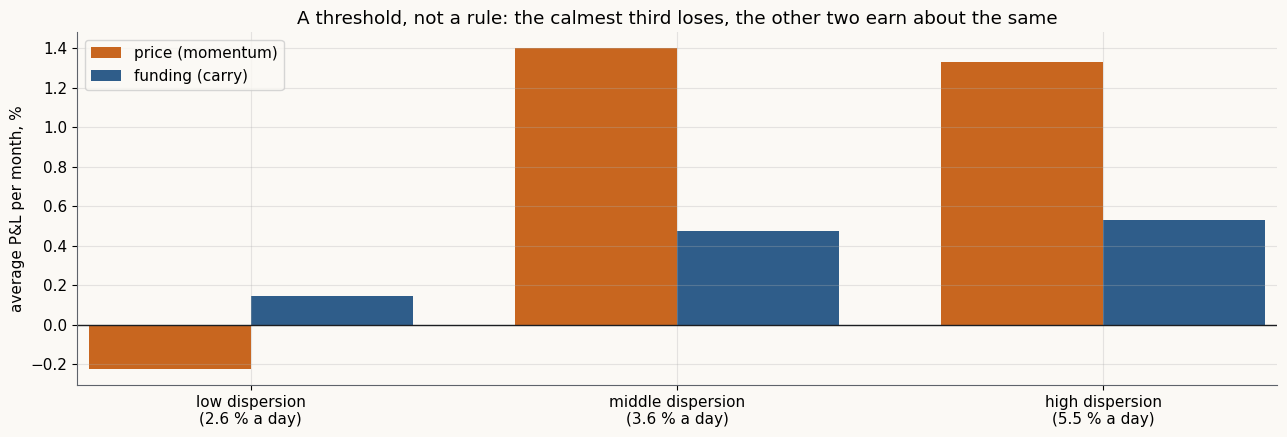

In [29]:
D = pd.concat([DISP_M.rename("dispersion"), RM], axis=1)
hi = D["dispersion"] > D["dispersion"].median()
halves = pd.DataFrame({"months": [hi.sum(), (~hi).sum()],
                       "total % / month": [D.total[hi].mean(), D.total[~hi].mean()],
                       "months positive %": [(D.total[hi] > 0).mean() * 100, (D.total[~hi] > 0).mean() * 100]},
                      index=["high dispersion", "low dispersion"]).round(2)
print(halves.to_string(), "\n")

D["third"] = pd.qcut(D["dispersion"], 3, labels=["low", "middle", "high"])
thirds = D.groupby("third", observed=True).agg(months=("total", "size"), dispersion=("dispersion", "mean"),
                                              total=("total", "mean"), price=("price", "mean"), funding=("funding", "mean"))
thirds["positive %"] = D.groupby("third", observed=True)["total"].apply(lambda x: (x > 0).mean() * 100)
print(thirds.round(2).to_string())

x = np.arange(3); w = .38
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - w / 2, thirds["price"], w, color=ORANGE, label="price (momentum)")
ax.bar(x + w / 2, thirds["funding"], w, color=BLUE, label="funding (carry)")
ax.axhline(0, color=DARK, lw=1)
ax.set_xticks(x, [f"{t} dispersion\n({v:.1f} % a day)" for t, v in zip(thirds.index, thirds["dispersion"])])
ax.set_ylabel("average P&L per month, %"); ax.legend()
ax.set_title("A threshold, not a rule: the calmest third loses, the other two earn about the same")
plt.tight_layout(); plt.show()

## 26. How strong is the link?

Correlation month by month (classic and on ranks), the t-stat of the high/low gap, and whether last month's dispersion says anything about the next one.

         correlation  rank correlation  t-stat, high vs low  last month's dispersion vs this month
total           0.06              0.16                 1.10                                  -0.09
price           0.02              0.16                 0.79                                  -0.11
funding         0.21              0.23                 1.87                                   0.09


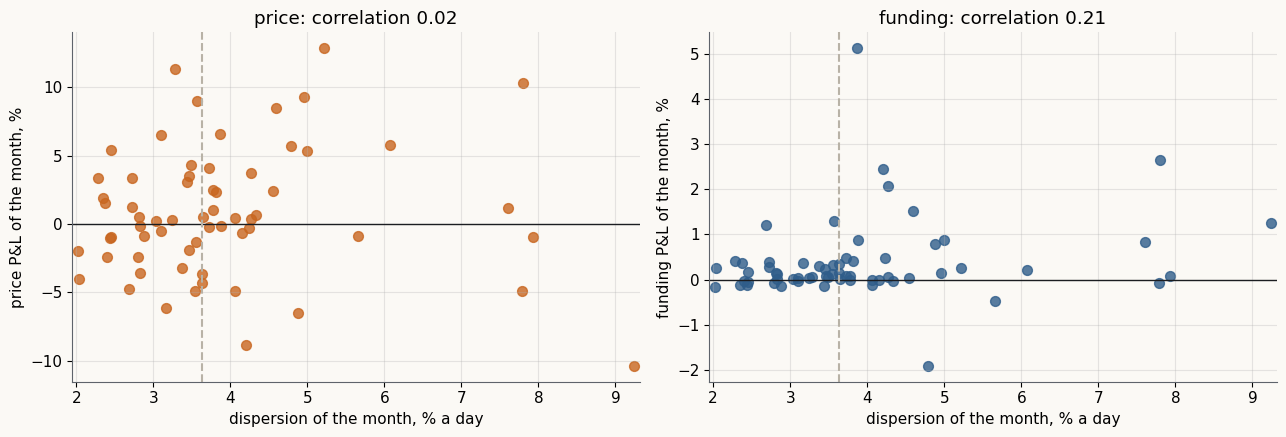

In [30]:
def tdiff(a, b):
    return (a.mean() - b.mean()) / np.sqrt(a.var() / len(a) + b.var() / len(b))
rk = D[["dispersion", "total", "price", "funding"]].rank()
check = pd.DataFrame({c: {"correlation": D["dispersion"].corr(D[c]), "rank correlation": rk["dispersion"].corr(rk[c]),
                          "t-stat, high vs low": tdiff(D[c][hi], D[c][~hi]),
                          "last month's dispersion vs this month": D["dispersion"].shift(1).corr(D[c])}
                      for c in ("total", "price", "funding")}).T.round(2)
print(check.to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for a, c, col in ((ax[0], "price", ORANGE), (ax[1], "funding", BLUE)):
    a.scatter(D["dispersion"], D[c], s=50, color=col, alpha=.8)
    a.axhline(0, color=DARK, lw=1); a.axvline(D["dispersion"].median(), color=GREY, ls="--")
    a.set_xlabel("dispersion of the month, % a day"); a.set_ylabel(f"{c} P&L of the month, %")
    a.set_title(f"{c}: correlation {D['dispersion'].corr(D[c]):.2f}")
plt.tight_layout(); plt.show()

The link goes the way Pass 1 said, but it is weak, a threshold rather than a line, and it does not predict next month. It explains the past; it does not time the future.

## 27. Year by year

      price  funding  total  dispersion
date                                   
2021    4.1      0.1    4.1         3.9
2022   -2.1     -2.5   -6.5         3.3
2023    7.6     10.7   15.3         3.3
2024   22.9      2.1   23.2         3.7
2025   19.4      4.9   23.8         3.5
2026    0.7      8.9    6.8         6.9


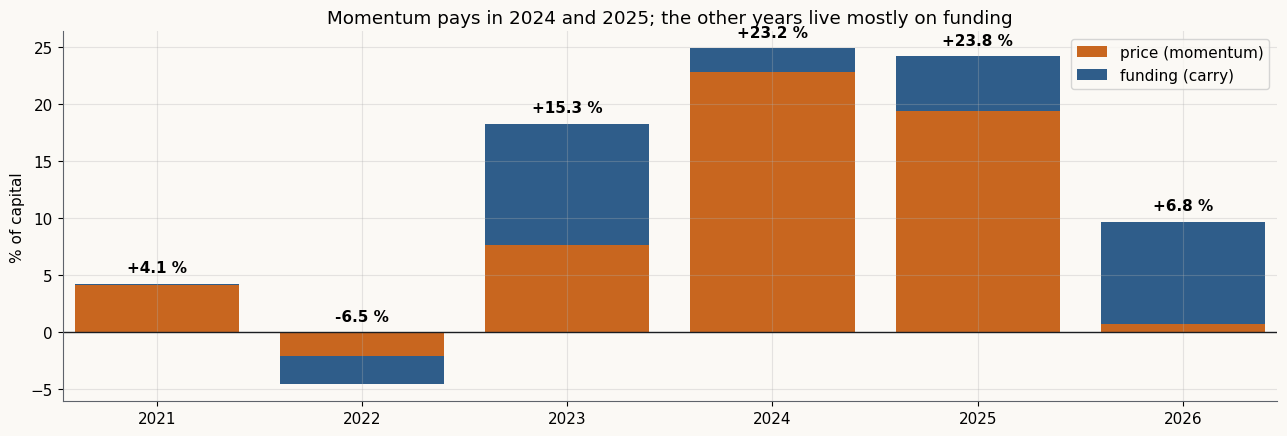

In [31]:
Y = R2[["price", "funding"]].groupby(R2.index.year).sum() * 100
Y["total"] = R2["total"].groupby(R2.index.year).apply(lambda g: ((1 + g).prod() - 1) * 100)
Y["dispersion"] = DISP_M.groupby(DISP_M.index.year).mean()
print(Y.round(1).to_string())
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(Y.index, Y["price"], color=ORANGE, label="price (momentum)")
ax.bar(Y.index, Y["funding"], bottom=np.where(Y["funding"] > 0, Y["price"].clip(lower=0), Y["price"].clip(upper=0)), color=BLUE, label="funding (carry)")
for yr, t in Y["total"].items():
    top_ = max(Y.loc[yr, "price"], 0) + max(Y.loc[yr, "funding"], 0)
    ax.annotate(f"{t:+.1f} %", (yr, top_ + 1 if t > 0 else 1), ha="center", fontweight="bold")
ax.axhline(0, color=DARK, lw=1); ax.set_ylabel("% of capital"); ax.legend()
ax.set_title("Momentum pays in 2024 and 2025; the other years live mostly on funding"); plt.tight_layout(); plt.show()

## 28. Concentration: a few names, a few days

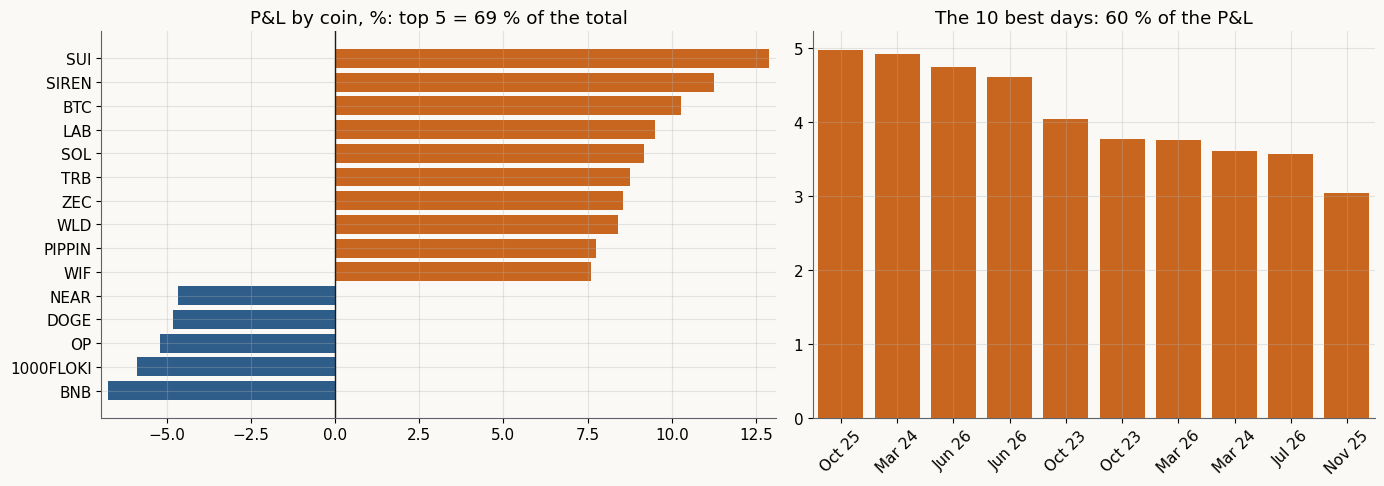

Sharpe 0.74; without the 10 best days 0.32


In [32]:
by_name = ((P2.shift(1) * PX.pct_change(fill_method=None) - P2.shift(1) * FUND).fillna(0).sum() * 100).sort_values()
top = pd.concat([by_name.head(5), by_name.tail(10)])
fig, ax = plt.subplots(1, 2, figsize=(14, 5), width_ratios=[1.2, 1])
ax[0].barh([nm(c) for c in top.index], top, color=np.where(top > 0, ORANGE, BLUE)); ax[0].axvline(0, color=DARK, lw=1)
ax[0].set_title(f"P&L by coin, %: top 5 = {by_name.tail(5).sum() / by_name.sum() * 100:.0f} % of the total")
r = R2["total"]; best = r.nlargest(10); without = r.drop(best.index)
ax[1].bar(range(10), best.values * 100, color=ORANGE); ax[1].set_xticks(range(10), [f"{d:%b %y}" for d in best.index], rotation=45)
ax[1].set_title(f"The 10 best days: {best.sum() / r.sum() * 100:.0f} % of the P&L")
plt.tight_layout(); plt.show()
print(f"Sharpe {r.mean() / r.std() * np.sqrt(PPY):.2f}; without the 10 best days {without.mean() / without.std() * np.sqrt(PPY):.2f}")

## What to take away from Part 4

- The strategy loses in the calmest third of the months and earns in the rest, as Pass 1 said.
- The link is weak and does not predict: it explains, it does not time.
- Momentum paid mainly in 2024 and 2025; the other years live mostly on funding.

# Part 5 · Lesson 2.10: what the Sharpe is really worth

## 29. Nine tries, we kept the best one

The net Sharpe of each design try (Research Log) and the version we kept. Then what luck alone gives: the average best Sharpe of N strategies with no edge, over the same 5.2 years.

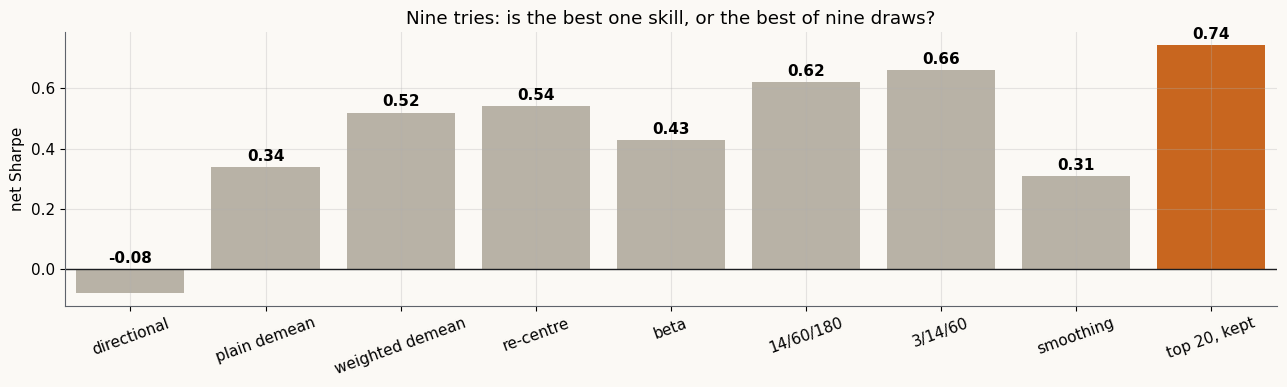

average best Sharpe of N no-edge strategies over 5.2 years (5,000 simulations):
1     0.00
3     0.38
9     0.66
20    0.82
50    0.99


In [33]:
T = len(R2) / PPY
tries = pd.Series({"directional": -0.08, "plain demean": 0.34, "weighted demean": 0.52, "re-centre": 0.54, "beta": 0.43,
                   "14/60/180": 0.62, "3/14/60": 0.66, "smoothing": 0.31, "top 20, kept": R2["total"].mean() / R2["total"].std() * np.sqrt(PPY)})
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(tries.index, tries, color=[ORANGE if k == "top 20, kept" else GREY for k in tries.index]); ax.axhline(0, color=DARK, lw=1)
for k, v in enumerate(tries): ax.annotate(f"{v:.2f}", (k, max(v, 0) + 0.02), ha="center", fontweight="bold")
ax.set_ylabel("net Sharpe"); ax.set_title("Nine tries: is the best one skill, or the best of nine draws?")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

rng = np.random.default_rng(15)
best = {n: np.mean([rng.normal(0, 1 / np.sqrt(T), n).max() for _ in range(5000)]) for n in (1, 3, 9, 20, 50)}
print("average best Sharpe of N no-edge strategies over 5.2 years (5,000 simulations):")
print(pd.Series(best).round(2).to_string())

## 30. Our tries are almost the same strategy

Five variants we can rebuild, and the correlation of their daily returns. Effective tries = N ÷ (1 + (N − 1) × ρ), the same rule as the IDM. The measured ρ is kind (not every try can be rebuilt), so we count with **ρ = 0.5**.

                7/30/90 (ours)  14/60/180  3/14/60  no smoothing  plain demean
7/30/90 (ours)            1.00       0.86     0.91          0.97          0.86
14/60/180                 0.86       1.00     0.81          0.81          0.75
3/14/60                   0.91       0.81     1.00          0.93          0.78
no smoothing              0.97       0.81     0.93          1.00          0.84
plain demean              0.86       0.75     0.78          0.84          1.00


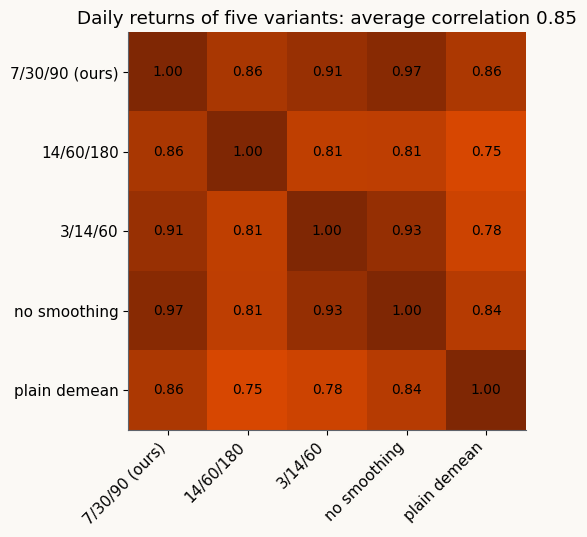

rho
0.00    9.0
0.30    2.6
0.50    1.8
0.85    1.2


In [34]:
def make_signal(H=HORIZONS, smooth=True):
    sp = {}
    for h in H:
        s = Z.rolling(h, min_periods=h).sum().shift(1)
        if smooth:
            s = s.ewm(span=max(2, round(h / 4)), min_periods=1).mean()
        sp[h] = s / np.sqrt(h)
    return sum(sp.values()) / 3 * FDM

def plain_demean(raw, members, cap=20):
    w = members.div(members.sum(axis=1), axis=0).fillna(0.0)
    f = raw.where(members); f = f.sub(f.mean(axis=1), axis=0)
    f = f.mul(10 / f.abs().mean(axis=1).expanding(min_periods=PPY).mean(), axis=0)
    for _ in range(20):
        f = f.clip(-cap, cap); f = f.sub(f.mean(axis=1), axis=0)
    return f.where(members, 0.0), w

variants = {"7/30/90 (ours)": R2["total"]}
for name, H in (("14/60/180", (14, 60, 180)), ("3/14/60", (3, 14, 60))):
    variants[name] = run(*cross_sectional_forecast(make_signal(H), M_PIT))[1]["total"]
variants["no smoothing"] = run(*cross_sectional_forecast(make_signal(smooth=False), M_PIT))[1]["total"]
variants["plain demean"] = run(*plain_demean(raw, M_PIT))[1]["total"]
V = pd.DataFrame(variants).dropna()
Cv = V.corr(); n = len(Cv)
rho_v = (Cv.values.sum() - n) / (n * (n - 1))
print(Cv.round(2).to_string())

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(Cv, cmap="Oranges", vmin=0, vmax=1)
ax.set_xticks(range(n), Cv.columns, rotation=45, ha="right"); ax.set_yticks(range(n), Cv.index)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{Cv.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_title(f"Daily returns of five variants: average correlation {rho_v:.2f}"); ax.grid(False)
plt.tight_layout(); plt.show()

N_TRIES, RHO = 9, 0.5                                   # RHO: our cautious assumption
eff = lambda rho: N_TRIES / (1 + (N_TRIES - 1) * rho)
n_eff, N_EFF = eff(rho_v), eff(RHO)
print(pd.Series({rho: eff(rho) for rho in (0.0, 0.3, RHO, round(rho_v, 2))}, name="effective tries").rename_axis("rho").round(1).to_string())

## 31. The luck line and the haircut

Luck line: the best Sharpe expected from N independent tries with no edge (Bailey and López de Prado; see the Deflated Sharpe note). Haircut: our Sharpe minus the luck line. Then the probability that the true Sharpe beats it (no skew or fat-tail correction).

luck line for 9 independent tries (the simulation of section 29 gives about the same): 9 tries -> 0.67
                          effective tries  luck line  our Sharpe  P(true Sharpe > luck line)
9 independent tries                  9.00       0.67        0.74                        0.57
ours, cautious (rho 0.5)             1.80       0.18        0.74                        0.90
measured (rho 0.85)                  1.15       0.00        0.74                        0.95


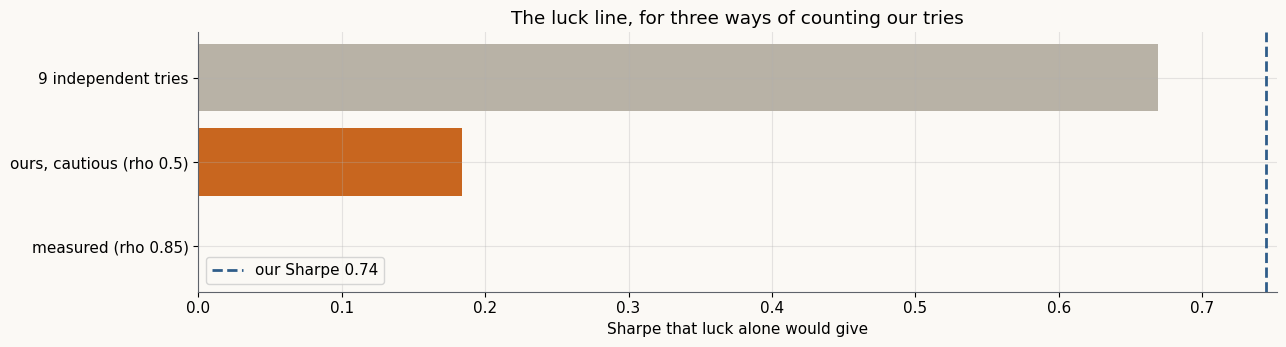


the haircut, by number of independent tries:
                   luck line  Sharpe left after the haircut
independent tries                                          
1.0                     0.00                           0.74
1.8                     0.18                           0.56
3.0                     0.38                           0.37
5.0                     0.52                           0.22
9.0                     0.67                           0.08
20.0                    0.84                           0.00


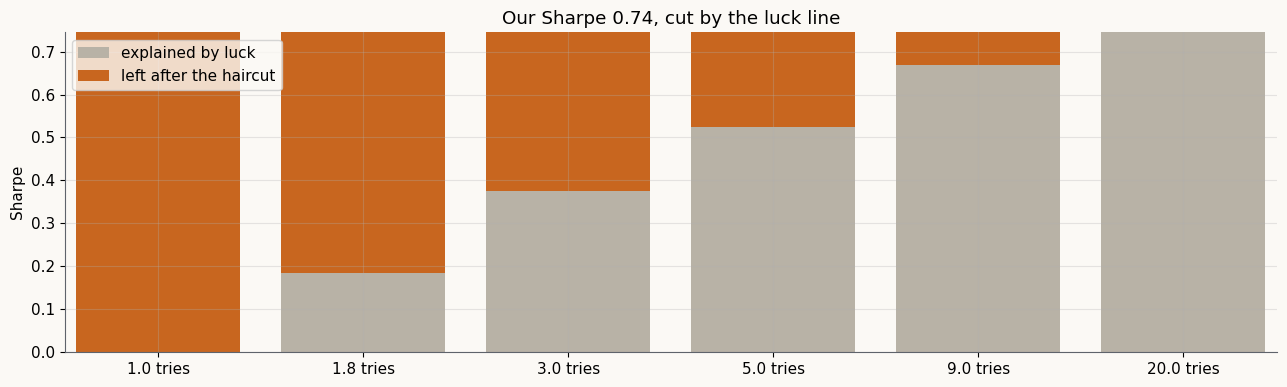

In [35]:
from statistics import NormalDist
Phi, Phi_inv = NormalDist().cdf, NormalDist().inv_cdf
EULER = 0.5772
def luck_line(n, T):
    """Expected best Sharpe of n zero-edge strategies over T years (Bailey and Lopez de Prado)."""
    if n <= 1: return 0.0
    return max(0.0, ((1 - EULER) * Phi_inv(1 - 1 / n) + EULER * Phi_inv(1 - 1 / (n * np.e))) / np.sqrt(T))
print(f"luck line for 9 independent tries (the simulation of section 29 gives about the same): 9 tries -> {luck_line(9, T):.2f}")
sr = R2["total"].mean() / R2["total"].std() * np.sqrt(PPY)
rows = {}
for lab, ne in (("9 independent tries", 9.0), ("ours, cautious (rho 0.5)", N_EFF), (f"measured (rho {rho_v:.2f})", n_eff)):
    line = luck_line(ne, T)
    rows[lab] = {"effective tries": ne, "luck line": line, "our Sharpe": sr, "P(true Sharpe > luck line)": Phi((sr - line) * np.sqrt(T))}
tab = pd.DataFrame(rows).T
print(tab.round(2).to_string())

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.barh(tab.index[::-1], tab["luck line"][::-1], color=[GREY, ORANGE, GREY])
ax.axvline(sr, color=BLUE, ls="--", lw=2, label=f"our Sharpe {sr:.2f}")
ax.set_xlabel("Sharpe that luck alone would give"); ax.legend(); ax.set_title("The luck line, for three ways of counting our tries")
plt.tight_layout(); plt.show()

hair = pd.DataFrame({"luck line": [luck_line(n, T) for n in (1, N_EFF, 3, 5, 9, 20)]}, index=[1, round(N_EFF, 1), 3, 5, 9, 20])
hair.index.name = "independent tries"
hair["Sharpe left after the haircut"] = (sr - hair["luck line"]).clip(lower=0)
print("\nthe haircut, by number of independent tries:")
print(hair.round(2).to_string())
fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(len(hair))
ax.bar(x, hair["luck line"].clip(upper=sr), color=GREY, label="explained by luck")
ax.bar(x, hair["Sharpe left after the haircut"], bottom=hair["luck line"].clip(upper=sr), color=ORANGE, label="left after the haircut")
ax.set_xticks(x, [f"{i} tries" for i in hair.index]); ax.set_ylabel("Sharpe"); ax.legend()
ax.set_title(f"Our Sharpe {sr:.2f}, cut by the luck line"); plt.tight_layout(); plt.show()

## What to take away from Part 5

- Count the choices made on a result (about 9 here), then how different they really are (1.8 at ρ = 0.5).
- Luck line 0.18, haircut Sharpe 0.56. Past about 13 independent tries, 0.74 would be all luck.
- What remains is the short history: about one chance in ten that it is luck. Promising, not proven.